# import libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# upload dataset

In [8]:
df = pd.read_csv("C:/Users/u21629545/Downloads/mike/mike/final.csv")

In [9]:
df.dtypes

Time              int64
Protcol          object
Flag             object
Family           object
Clusters          int64
SeddAddress      object
ExpAddress       object
BTC               int64
USD               int64
Netflow_Bytes     int64
IPaddress        object
Threats          object
Port              int64
Prediction       object
dtype: object

#   dataset info

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149043 entries, 0 to 149042
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Time           149043 non-null  int64 
 1   Protcol        149043 non-null  object
 2   Flag           149043 non-null  object
 3   Family         149043 non-null  object
 4   Clusters       149043 non-null  int64 
 5   SeddAddress    149043 non-null  object
 6   ExpAddress     149043 non-null  object
 7   BTC            149043 non-null  int64 
 8   USD            149043 non-null  int64 
 9   Netflow_Bytes  149043 non-null  int64 
 10  IPaddress      149043 non-null  object
 11  Threats        149043 non-null  object
 12  Port           149043 non-null  int64 
 13  Prediction     149043 non-null  object
dtypes: int64(6), object(8)
memory usage: 15.9+ MB


# Data Preprocessing

In [11]:
df.isnull().sum()

Time             0
Protcol          0
Flag             0
Family           0
Clusters         0
SeddAddress      0
ExpAddress       0
BTC              0
USD              0
Netflow_Bytes    0
IPaddress        0
Threats          0
Port             0
Prediction       0
dtype: int64

In [12]:
# Check for duplicates raws
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")


Number of duplicate rows: 0


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,149043.0,21.466979,15.883598,-10.0,8.0,19.0,32.0,96.0
Clusters,149043.0,2.349295,2.828759,1.0,1.0,1.0,2.0,12.0
BTC,149043.0,30.554605,101.447102,1.0,8.0,13.0,22.0,1980.0
USD,149043.0,14863.441114,26849.434659,1.0,512.0,4321.0,18454.0,126379.0
Netflow_Bytes,149043.0,2021.278651,2271.420987,1.0,353.0,1031.0,3188.0,12360.0
Port,149043.0,5063.949967,2.696011,5061.0,5062.0,5062.0,5066.0,5068.0


# remove negative values from time 

In [14]:
# Remove rows where the 'Time' column has negative values
df = df[df['Time'] >= 0]

# Reset the index to start from 0 and drop the old index column
df.reset_index(drop=True, inplace=True)
df.shape

(148904, 14)

# remove invalid ExpAddress

In [15]:
# Drop rows where the 'ExpAddress' value is  '1' 
df = df[df['ExpAddress'] != '1']
df.shape


(148831, 14)

In [16]:
# Display the data types of each column
print(df.dtypes)

Time              int64
Protcol          object
Flag             object
Family           object
Clusters          int64
SeddAddress      object
ExpAddress       object
BTC               int64
USD               int64
Netflow_Bytes     int64
IPaddress        object
Threats          object
Port              int64
Prediction       object
dtype: object


# check outliers

In [17]:
# List of numerical columns 
numerical_columns = ['Time', 'Clusters', 'BTC', 'USD', 'Netflow_Bytes', 'Port']

# Check for outliers with Z-score > 3 or < -3
outliers = pd.DataFrame()

# Calculate the Z-scores and identify outliers
for col in numerical_columns:
    mean = df[col].mean()
    std_dev = df[col].std()
    
    # Calculate Z-scores for the column
    z_scores = (df[col] - mean) / std_dev
    
    # Identify outliers: Z-score > 3 or Z-score < -3
    col_outliers = df[np.abs(z_scores) > 3]
    
    # Append outliers to the outliers DataFrame
    outliers = pd.concat([outliers, col_outliers])
    
# Remove duplicates in case multiple columns have the same outliers
outliers = outliers.drop_duplicates()

# Display the outliers
if not outliers.empty:
    print("Outliers (Z-score > 3 or < -3):")
    print(outliers)
else:
    print("No outliers found.")


Outliers (Z-score > 3 or < -3):
        Time Protcol Flag    Family  Clusters SeddAddress ExpAddress  BTC  \
42        70     TCP    A  WannaCry         1    1DA11mPS   1BonuSr7   18   
45        74     TCP    A  WannaCry         1    1DA11mPS   1BonuSr7   18   
46        70     TCP    A  WannaCry         1    1DA11mPS   1BonuSr7   18   
10437     70     TCP    A  CryptXXX         1    17dcMo4V   1CLag5cd   18   
10440     74     TCP    A  CryptXXX         1    17dcMo4V   1CLag5cd   18   
...      ...     ...  ...       ...       ...         ...        ...  ...   
140734    22     UDP    R      Razy         2    17dcMo4V   1CLag5cd  142   
140735    21     UDP    R      Razy         2    17dcMo4V   1CLag5cd  138   
140736    20     UDP    R      Razy         2    17dcMo4V   1CLag5cd  134   
140737    19     UDP    R      Razy         2    17dcMo4V   1CLag5cd  130   
140738    18     UDP    R      Razy         2    17dcMo4V   1CLag5cd  126   

         USD  Netflow_Bytes IPaddress Threa

# remove outliers

In [18]:
from scipy.stats import zscore
# Select numerical columns to calculate Z-scores
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate Z-scores for the numerical columns
z_scores = zscore(df[numerical_columns])

# Create a boolean mask where rows with z-score > 3 or < -3 will be removed
mask = (z_scores < 3) & (z_scores > -3)

# Apply the mask to remove rows with outliers
df_cleaned = df[mask.all(axis=1)]  # This ensures all columns have valid Z-scores

# Check the shape of the DataFrame after removing outliers
print("Data shape after removing outliers:", df_cleaned.shape)

# Save the cleaned DataFrame to a CSV file
df_cleaned.to_csv('lidet.csv', index=False)
df=df_cleaned


Data shape after removing outliers: (132115, 14)


# labling incorrectly named 

In [19]:
# Filter for rows where the "Threats" column contains "Bonet" and "NerisBotnet"

# Replace "Bonet" with "Botnet" in the entire DataFrame
df = df.replace('Bonet', 'Botnet', regex=True)

# Replace "Bonet" with "Botnet" in the entire DataFrame
df = df.replace('NerisBonet', 'NerisBotnet', regex=True)


In [20]:
# Rename columns
df = df.rename(columns={'Protcol': 'Protocol', 'SeddAddress': 'SeedAddress'})


# merge family column 

In [21]:
# Get the frequency of each category in the 'Family' column
family_counts = df['Family'].value_counts()

# Identify families with occurrences below 4000
rare_families = family_counts[family_counts < 4000].index.tolist()

# Use .loc[] to avoid the SettingWithCopyWarning
df.loc[df['Family'].isin(rare_families), 'Family'] = 'Other'

# Verify the changes by checking the value counts
print(df['Family'].value_counts())

# Save the modified DataFrame to a new CSV file
df.to_csv('updated_family_dataset.csv', index=False)


Family
Locky        23151
SamSam       17510
WannaCry     14892
JigSaw       11697
Flyper       10200
DMALocker     9553
CryptXXX      9151
APT           9084
Other         8300
Globe         6979
Razy          6885
EDA2          4713
Name: count, dtype: int64


# lable encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
lab_encoder = LabelEncoder()

# Apply LabelEncoder to all categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = lab_encoder.fit_transform(df[col])

# Display the head of the transformed dataframe to verify
print(df.head())

   Time  Protocol  Flag  Family  Clusters  SeedAddress  ExpAddress  BTC  USD  \
0    50         1     0      11         1            2           1    1  500   
1    40         1     0      11         1            2           1    1  504   
2    30         1     0      11         1            2           1    1  508   
3    20         1     0      11         1            2           1    1  512   
4    57         1     0      11         1            2           1    1  516   

   Netflow_Bytes  IPaddress  Threats  Port  Prediction  
0              5          0        1  5061           2  
1              8          0        1  5061           2  
2              7          0        1  5061           2  
3             15          0        1  5061           2  
4              9          0        1  5061           2  


# feature engineering

In [23]:
# Feature Engineering
import numpy as np

df['BTC_USD_Ratio'] = np.where(df['USD'] != 0, df['BTC'] / df['USD'], 0)
df['Total_Bytes'] = df.groupby('IPaddress')['Netflow_Bytes'].transform('sum')  # Aggregate bytes per IP
df['hour_of_day'] = df['Time'] % 24
df['day_of_week'] = (df['Time'] // 24) % 7  # Assuming 'Time' is in hours



In [24]:
# Group by 'Family' and calculate the mean of 'BTC', 'USD', and 'Netflow_Bytes'
family_stats = df.groupby('Family')[['BTC', 'USD', 'Netflow_Bytes']].mean().reset_index()

# Display the results
print(family_stats)

    Family        BTC           USD  Netflow_Bytes
0        0  22.499890   4783.748239    2233.304271
1        1  16.921539  10376.107748    2000.116490
2        2  20.776091   9284.476500    2169.102481
3        3  15.352217  14948.950987    2300.129429
4        4  21.429510   8616.160686    2115.430098
5        5  18.815590   7538.221378    1584.863877
6        6  21.651107   8220.377276    1633.398136
7        7  18.586800  11343.148676    2129.333161
8        8  35.430241  10984.773614    2019.623614
9        9  30.900944   9660.049673    2231.863326
10      10  21.934552  11194.093604    1842.774700
11      11  19.485966  10631.441982    1765.652162


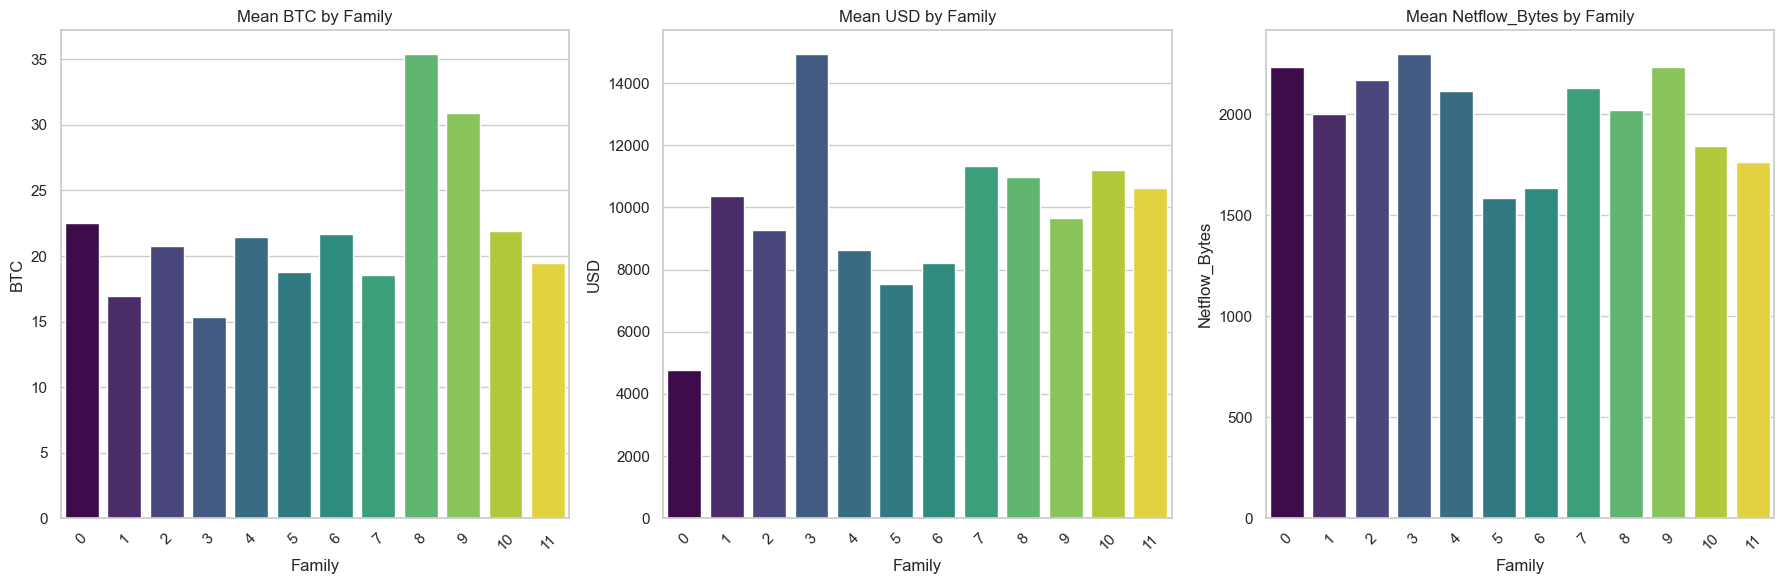

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = "viridis"

# Plot mean BTC by family
sns.barplot(x='Family', y='BTC', hue='Family', data=family_stats, ax=axes[0],
            palette=palette, legend=False)
axes[0].set_title('Mean BTC by Family')
axes[0].tick_params(axis='x', rotation=45)

# Plot mean USD by family
sns.barplot(x='Family', y='USD', hue='Family', data=family_stats, ax=axes[1],
            palette=palette, legend=False)
axes[1].set_title('Mean USD by Family')
axes[1].tick_params(axis='x', rotation=45)

# Plot mean Netflow_Bytes by family
sns.barplot(x='Family', y='Netflow_Bytes', hue='Family', data=family_stats, ax=axes[2],
            palette=palette, legend=False)
axes[2].set_title('Mean Netflow_Bytes by Family')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [26]:
# Rename columns in family_stats to avoid conflicts
family_stats = family_stats.rename(columns={
    'BTC': 'Mean_BTC',
    'USD': 'Mean_USD',
    'Netflow_Bytes': 'Mean_Netflow_Bytes'
})

# Merge the mean stats back into the original dataset
df = df.merge(family_stats, on='Family')
# Save processed dataset


In [30]:
import pandas as pd
import numpy as np
import pennylane as qml

In [31]:
df

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,...,Threats,Port,Prediction,BTC_USD_Ratio,Total_Bytes,hour_of_day,day_of_week,Mean_BTC,Mean_USD,Mean_Netflow_Bytes
0,1.783576,1,0,11,1,2,1,-0.532249,-0.748207,-0.990255,...,1,5061,2,0.002000,57814424,2,2,19.485966,10631.441982,1765.652162
1,1.159232,1,0,11,1,2,1,-0.532249,-0.747889,-0.988752,...,1,5061,2,0.001984,57814424,16,1,19.485966,10631.441982,1765.652162
2,0.534887,1,0,11,1,2,1,-0.532249,-0.747571,-0.989253,...,1,5061,2,0.001969,57814424,6,1,19.485966,10631.441982,1765.652162
3,-0.089458,1,0,11,1,2,1,-0.532249,-0.747253,-0.985247,...,1,5061,2,0.001953,57814424,20,0,19.485966,10631.441982,1765.652162
4,2.220618,1,0,11,1,2,1,-0.532249,-0.746935,-0.988252,...,1,5061,2,0.001938,57814424,9,2,19.485966,10631.441982,1765.652162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132110,0.722190,0,2,8,3,1,5,7.685618,-0.744071,-0.273069,...,6,5062,0,0.576087,57814424,9,1,35.430241,10984.773614,2019.623614
132111,0.722190,0,2,8,3,1,5,7.789313,-0.743594,-0.267560,...,6,5062,0,0.577061,57814424,9,1,35.430241,10984.773614,2019.623614
132112,0.722190,0,2,8,3,1,5,7.893009,-0.743117,-0.262051,...,6,5062,0,0.578014,57814424,9,1,35.430241,10984.773614,2019.623614
132113,0.722190,0,2,8,3,1,5,7.996704,-0.742640,-0.256541,...,6,5062,0,0.578947,57814424,9,1,35.430241,10984.773614,2019.623614


# normalize

In [32]:
# Step 3: Quantum Feature Mapping (QFM)
# -------------------------------
# Define number of qubits (use number of features to encode)
features_to_encode = ['BTC_USD_Ratio', 'Total_Bytes', 'hour_of_day', 'day_of_week', 'Mean_BTC', 'Mean_USD', 'Mean_Netflow_Bytes']
n_qubits = len(features_to_encode)
dev = qml.device('default.qubit', wires=n_qubits)

# PQC to encode features into quantum state using RZ rotations and entanglement
def qfm_circuit(x):
    for i in range(n_qubits):
        qml.RZ(x[i], wires=i)  # Encode classical feature into RZ rotation
    # Entanglement layer
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# QNode wrapper
qnode = qml.QNode(qfm_circuit, dev)

# Apply QFM to each row
qfm_features = df[features_to_encode].values
qfm_results = np.array([qnode(row) for row in qfm_features])

# Add QFM features to dataframe
for i in range(n_qubits):
    df[f'QFM_{i}'] = qfm_results[:, i]

# Save RZ values for reference
for i, feat in enumerate(features_to_encode):
    df[f'RZ_{feat}'] = df[feat]  # The rotation angles applied

# -------------------------------
# Step 4: Save final dataset
# -------------------------------
df.to_csv("RansomFEN-QFM_dataset.csv", index=False)

print("RansomFEN-QFM dataset saved with classical + quantum features.")

RansomFEN-QFM dataset saved with classical + quantum features.


In [33]:
import os
print(os.getcwd())

C:\Users\u21629545


       Time  Protocol  Flag  Family  Clusters  SeedAddress  ExpAddress  \
0  1.783576         1     0      11         1            2           1   
1  1.159232         1     0      11         1            2           1   
2  0.534887         1     0      11         1            2           1   
3 -0.089458         1     0      11         1            2           1   
4  2.220618         1     0      11         1            2           1   

        BTC       USD  Netflow_Bytes  ...  QFM_4  QFM_5  QFM_6  \
0 -0.532249 -0.748207      -0.990255  ...    1.0    1.0    1.0   
1 -0.532249 -0.747889      -0.988752  ...    1.0    1.0    1.0   
2 -0.532249 -0.747571      -0.989253  ...    1.0    1.0    1.0   
3 -0.532249 -0.747253      -0.985247  ...    1.0    1.0    1.0   
4 -0.532249 -0.746935      -0.988252  ...    1.0    1.0    1.0   

   RZ_BTC_USD_Ratio  RZ_Total_Bytes  RZ_hour_of_day  RZ_day_of_week  \
0          0.002000        57814424               2               2   
1          0.001

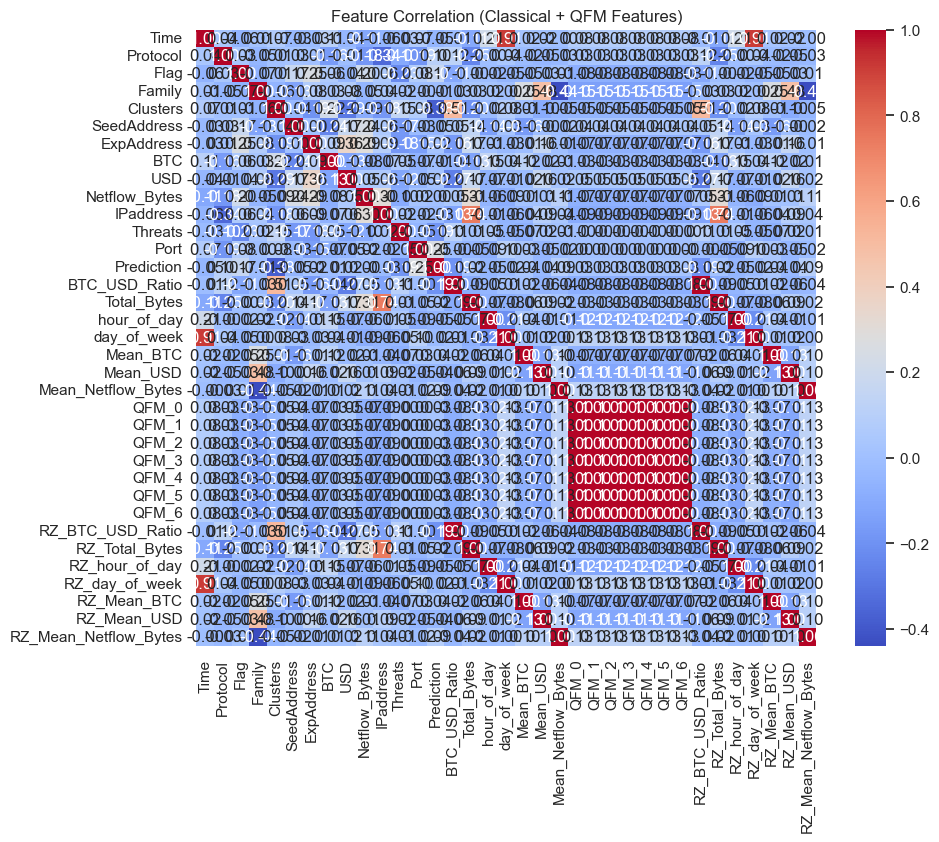

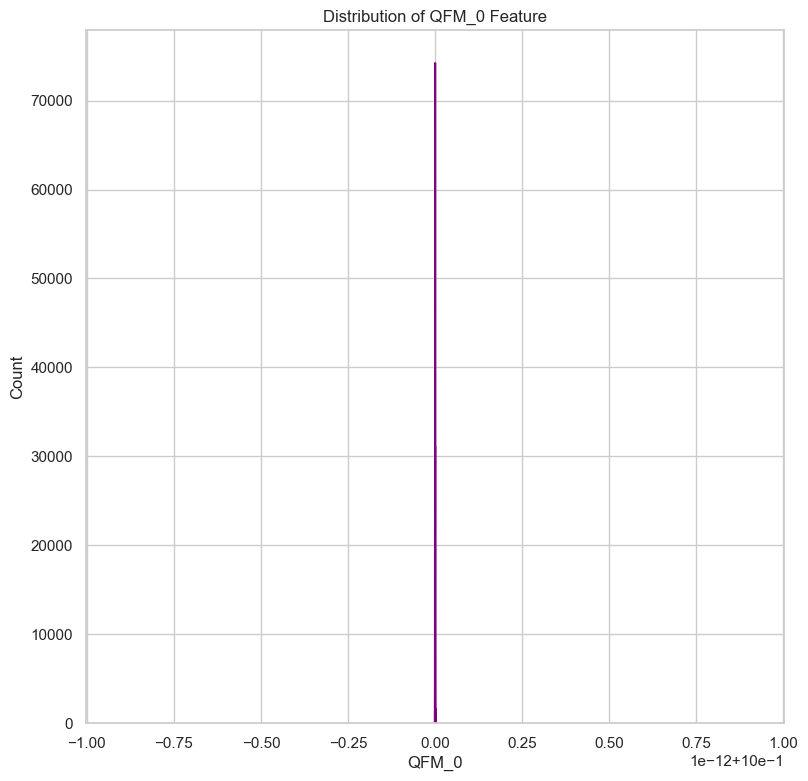

In [37]:
# Load the saved dataset
df = pd.read_csv("RansomFEN-QFM_dataset.csv")

# Show first few rows
print(df.head())

# Example: plot correlation matrix of features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation (Classical + QFM Features)")
plt.show()

# Example: plot a QFM feature distribution
plt.figure(figsize=(9,9))
sns.histplot(df['QFM_0'], bins=30, kde=True, color='purple')
plt.title("Distribution of QFM_0 Feature")
plt.show()

In [38]:
df

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,...,QFM_4,QFM_5,QFM_6,RZ_BTC_USD_Ratio,RZ_Total_Bytes,RZ_hour_of_day,RZ_day_of_week,RZ_Mean_BTC,RZ_Mean_USD,RZ_Mean_Netflow_Bytes
0,1.783576,1,0,11,1,2,1,-0.532249,-0.748207,-0.990255,...,1.0,1.0,1.0,0.002000,57814424,2,2,19.485966,10631.441982,1765.652162
1,1.159232,1,0,11,1,2,1,-0.532249,-0.747889,-0.988752,...,1.0,1.0,1.0,0.001984,57814424,16,1,19.485966,10631.441982,1765.652162
2,0.534887,1,0,11,1,2,1,-0.532249,-0.747571,-0.989253,...,1.0,1.0,1.0,0.001969,57814424,6,1,19.485966,10631.441982,1765.652162
3,-0.089458,1,0,11,1,2,1,-0.532249,-0.747253,-0.985247,...,1.0,1.0,1.0,0.001953,57814424,20,0,19.485966,10631.441982,1765.652162
4,2.220618,1,0,11,1,2,1,-0.532249,-0.746935,-0.988252,...,1.0,1.0,1.0,0.001938,57814424,9,2,19.485966,10631.441982,1765.652162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132110,0.722190,0,2,8,3,1,5,7.685618,-0.744071,-0.273069,...,1.0,1.0,1.0,0.576087,57814424,9,1,35.430241,10984.773614,2019.623614
132111,0.722190,0,2,8,3,1,5,7.789313,-0.743594,-0.267560,...,1.0,1.0,1.0,0.577061,57814424,9,1,35.430241,10984.773614,2019.623614
132112,0.722190,0,2,8,3,1,5,7.893009,-0.743117,-0.262051,...,1.0,1.0,1.0,0.578014,57814424,9,1,35.430241,10984.773614,2019.623614
132113,0.722190,0,2,8,3,1,5,7.996704,-0.742640,-0.256541,...,1.0,1.0,1.0,0.578947,57814424,9,1,35.430241,10984.773614,2019.623614


Quantum Encoding Circuit (Real Angles):
0: ──RZ(0.00)────────┤  <Z>
1: ──RZ(57814424.00)─┤  <Z>
2: ──RZ(2.00)────────┤  <Z>
3: ──RZ(2.00)────────┤  <Z>
4: ──RZ(19.49)───────┤  <Z>
5: ──RZ(10631.44)────┤  <Z>
6: ──RZ(1765.65)─────┤  <Z>


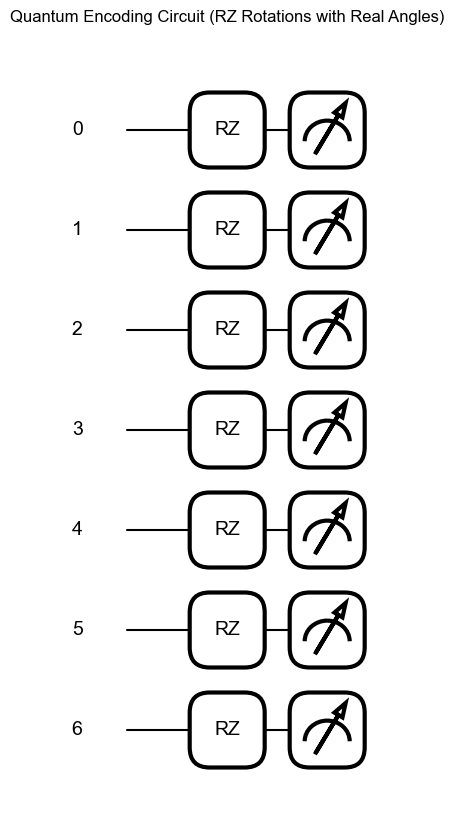

Full Quantum Circuit with Real Angles:
0: ──RZ(0.00)────────╭●────────────────┤  <Z>
1: ──RZ(57814424.00)─╰X─╭●─────────────┤  <Z>
2: ──RZ(2.00)───────────╰X─╭●──────────┤  <Z>
3: ──RZ(2.00)──────────────╰X─╭●───────┤  <Z>
4: ──RZ(19.49)────────────────╰X─╭●────┤  <Z>
5: ──RZ(10631.44)────────────────╰X─╭●─┤  <Z>
6: ──RZ(1765.65)────────────────────╰X─┤  <Z>


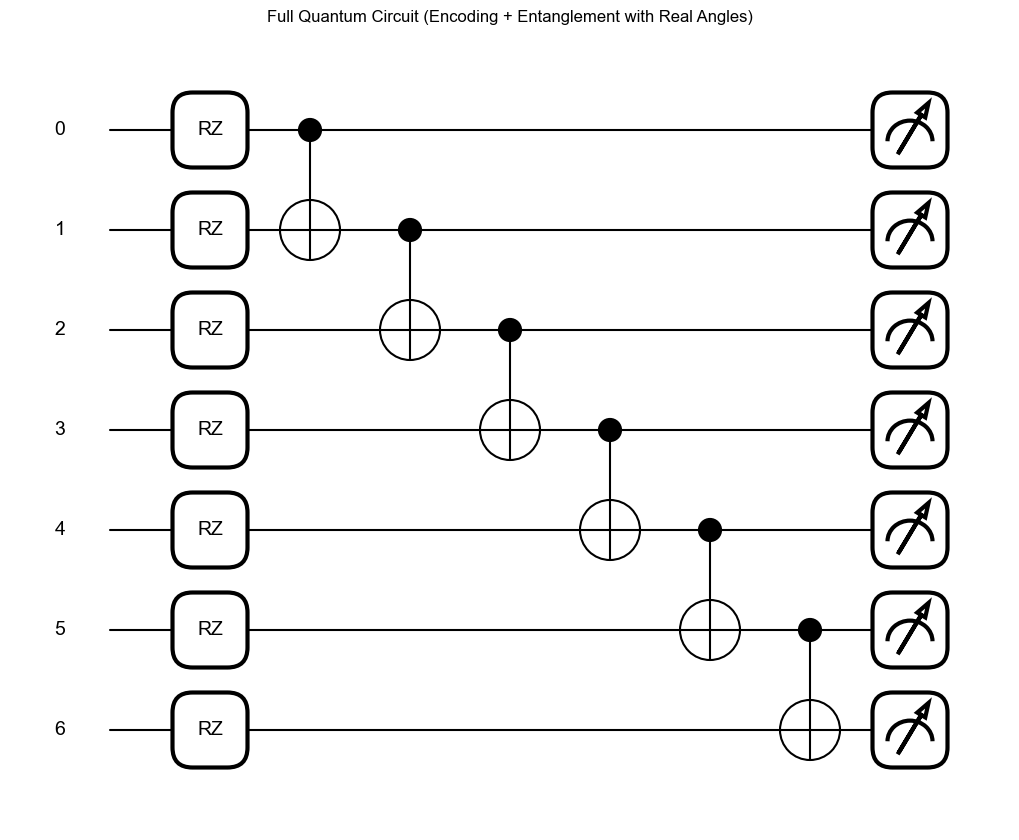

In [41]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("RansomFEN-QFM_dataset.csv")

# Features to encode
features_to_encode = ['BTC_USD_Ratio', 'Total_Bytes', 'hour_of_day', 
                      'day_of_week', 'Mean_BTC', 'Mean_USD', 'Mean_Netflow_Bytes']
n_qubits = len(features_to_encode)

# Pick a real row (first row for example)
sample_row = df[features_to_encode].iloc[0].values

# Device
dev = qml.device('default.qubit', wires=n_qubits)

# -------------------------------
# (a) Quantum Encoding Circuit (RZ only)
@qml.qnode(dev)
def encoding_circuit(x):
    for i in range(n_qubits):
        qml.RZ(x[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Draw text version
print("Quantum Encoding Circuit (Real Angles):")
print(qml.draw(encoding_circuit)(sample_row))

# Plot circuit
fig, ax = qml.draw_mpl(encoding_circuit)(sample_row)
ax.set_title("Quantum Encoding Circuit (RZ Rotations with Real Angles)")
plt.show()

# -------------------------------
# (b) Full Quantum Circuit with Entanglement
@qml.qnode(dev)
def full_qfm_circuit(x):
    # Encoding
    for i in range(n_qubits):
        qml.RZ(x[i], wires=i)
    # Entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Draw text version
print("Full Quantum Circuit with Real Angles:")
print(qml.draw(full_qfm_circuit)(sample_row))

# Plot circuit
fig, ax = qml.draw_mpl(full_qfm_circuit)(sample_row)
ax.set_title("Full Quantum Circuit (Encoding + Entanglement with Real Angles)")
plt.show()



In [42]:
from sklearn.preprocessing import StandardScaler

# Create a list of columns to normalize
numerical_columns = ['Time', 'BTC', 'USD', 'Netflow_Bytes',]

# Initialize the scaler
scaler = StandardScaler()

# Apply normalization
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Check the result
df.describe()


,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,...,QFM_4,QFM_5,QFM_6,RZ_BTC_USD_Ratio,RZ_Total_Bytes,RZ_hour_of_day,RZ_day_of_week,RZ_Mean_BTC,RZ_Mean_USD,RZ_Mean_Netflow_Bytes
count,1.321150e+05,132115.000000,132115.000000,132115.000000,132115.000000,132115.000000,132115.000000,1.321150e+05,1.321150e+05,1.321150e+05,...,1.321150e+05,1.321150e+05,1.321150e+05,132115.000000,1.321150e+05,132115.000000,132115.000000,132115.000000,132115.000000,132115.000000
mean,2.291119e-17,1.010059,3.803815,6.188601,1.866442,1.982871,2.640813,-3.269954e-17,-1.850106e-17,-1.290771e-17,...,1.000000e+00,1.000000e+00,1.000000e+00,1.231095,9.749408e+07,10.333770,0.462461,21.531249,9906.706210,1982.234281
std,1.000004e+00,0.736308,2.487293,3.441689,2.189126,1.261771,1.819452,1.000004e+00,1.000004e+00,1.000004e+00,...,2.812702e-16,2.812702e-16,2.812702e-16,3.653853,5.399494e+07,6.742943,0.668159,4.696314,2036.692437,214.391288
min,-1.338147e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-5.322495e-01,-7.878978e-01,-9.917574e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,0.000095,4.718356e+06,0.000000,0.000000,15.352217,4783.748239,1584.863877
25%,-8.386715e-01,0.000000,1.000000,4.000000,1.000000,2.000000,1.000000,-3.767062e-01,-7.487244e-01,-7.904244e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,0.000688,5.781442e+07,5.000000,0.000000,18.586800,8616.160686,1765.652162
50%,-1.518923e-01,1.000000,4.000000,7.000000,1.000000,2.000000,3.000000,-2.730108e-01,-5.689247e-01,-4.233173e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,0.001901,5.781442e+07,10.000000,0.000000,20.776091,10631.441982,2019.623614
75%,6.597558e-01,2.000000,6.000000,9.000000,2.000000,3.000000,5.000000,1.215183e-02,6.798499e-01,6.404421e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,0.031250,1.576201e+08,16.000000,1.000000,21.934552,11194.093604,2129.333161
max,2.969831e+00,2.000000,8.000000,11.000000,10.000000,4.000000,5.000000,8.100400e+00,5.928999e+00,3.432560e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,20.000000,1.576201e+08,23.000000,2.000000,35.430241,14948.950987,2300.129429


# train_test_split

In [43]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y) - Now using 'Prediction' as the target
X = df.drop(columns=['Prediction'])  
y = df['Prediction']  # Target column (Prediction)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the splits to confirm
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Test data shape (X_test): {X_test.shape}")


Training data shape (X_train): (105692, 34)
Test data shape (X_test): (26423, 34)


# Balance the classes using SMOTE

C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before balancing:
Prediction
1    45204
0    30327
2    30161
Name: count, dtype: int64

After balancing (SMOTE):
Prediction
2    45204
0    45204
1    45204
Name: count, dtype: int64


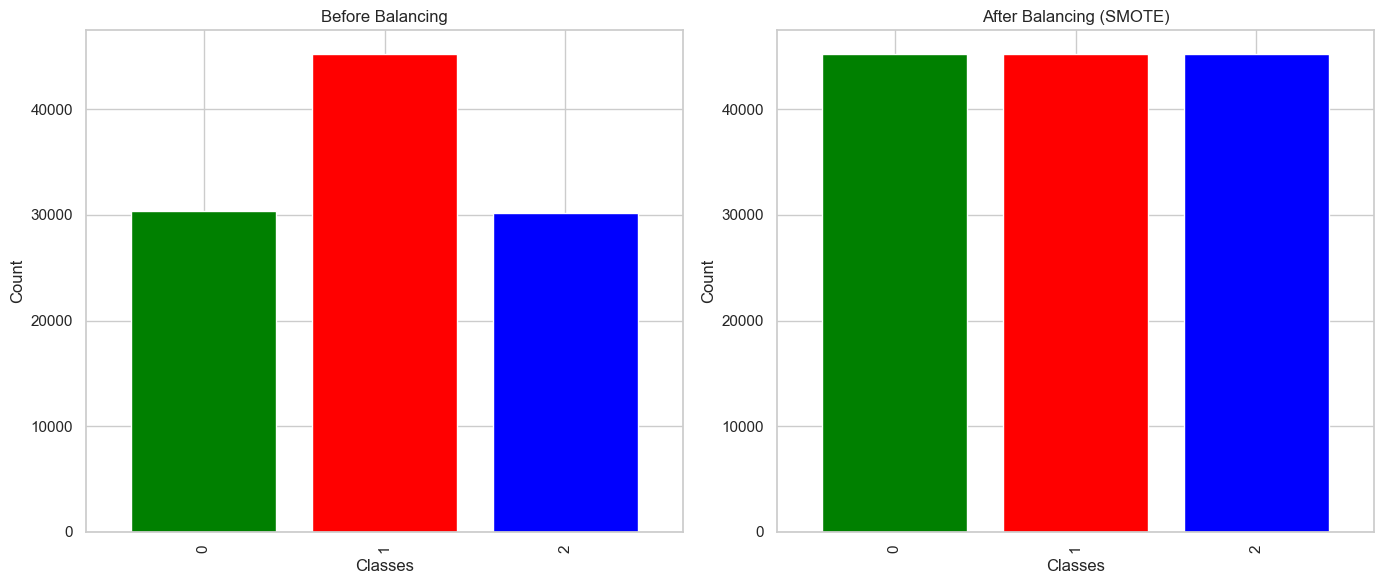

In [45]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Balance the classes using SMOTE only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Check the distribution of the target variable before balancing
print("Before balancing:")
print(y_train.value_counts())

# Check the distribution of the target variable after balancing
print("\nAfter balancing (SMOTE):")
print(y_train_balanced.value_counts())

# Define color mapping for each class
color_map = {0: 'green', 1: 'red', 2: 'blue'}

# Plot the distribution before and after balancing
plt.figure(figsize=(14, 6))

# Before balancing
plt.subplot(1, 2, 1)
y_train.value_counts().sort_index().plot(
    kind='bar',
    color=[color_map[x] for x in y_train.value_counts().sort_index().index],
    width=0.8
)
plt.title("Before Balancing")
plt.xlabel("Classes")
plt.ylabel("Count")

# After balancing
plt.subplot(1, 2, 2)
y_train_balanced.value_counts().sort_index().plot(
    kind='bar',
    color=[color_map[x] for x in y_train_balanced.value_counts().sort_index().index],
    width=0.8
)
plt.title("After Balancing (SMOTE)")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [46]:
# Train Random Forest on the balanced data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# Print that the training is complete
print("Random Forest training complete!")


Random Forest training complete!


Train Accuracy: 0.9983


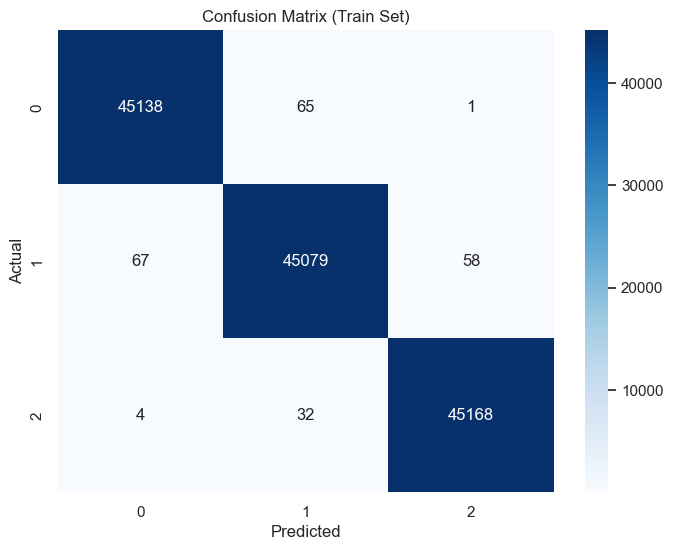

Classification Report (Train Set):
              precision    recall  f1-score   support

           0     0.9984    0.9985    0.9985     45204
           1     0.9979    0.9972    0.9975     45204
           2     0.9987    0.9992    0.9989     45204

    accuracy                         0.9983    135612
   macro avg     0.9983    0.9983    0.9983    135612
weighted avg     0.9983    0.9983    0.9983    135612



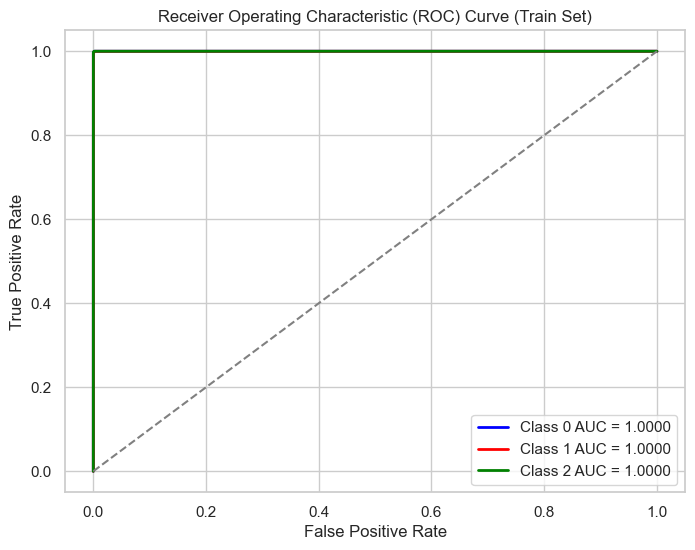

In [47]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
import matplotlib.pyplot as plt

# Binarize the target variable for multi-class AUC-ROC
lb = LabelBinarizer()
y_train_binarized = lb.fit_transform(y_train_balanced)

# Predict on the train set
y_train_pred = rf.predict(X_train_balanced)

# Train Accuracy 
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

# Confusion Matrix for Train Set (formatted with '.d' for integers)
cm_train = confusion_matrix(y_train_balanced, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='.0f', cmap='Blues', xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title("Confusion Matrix (Train Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report for Train Set with 4 decimal places
print("Classification Report (Train Set):")
print(classification_report(y_train_balanced, y_train_pred, digits=4))

# AUC-ROC for Train Set
fpr_train, tpr_train, roc_auc_train = {}, {}, {}
for i in range(len(lb.classes_)):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_binarized[:, i], rf.predict_proba(X_train_balanced)[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

# Plot AUC-ROC for Train Set
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i in range(len(lb.classes_)):
    plt.plot(fpr_train[i], tpr_train[i], color=colors[i], lw=2, label='Class {} AUC = {:.4f}'.format(lb.classes_[i], roc_auc_train[i]))

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve (Train Set)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Test Accuracy: 0.9936


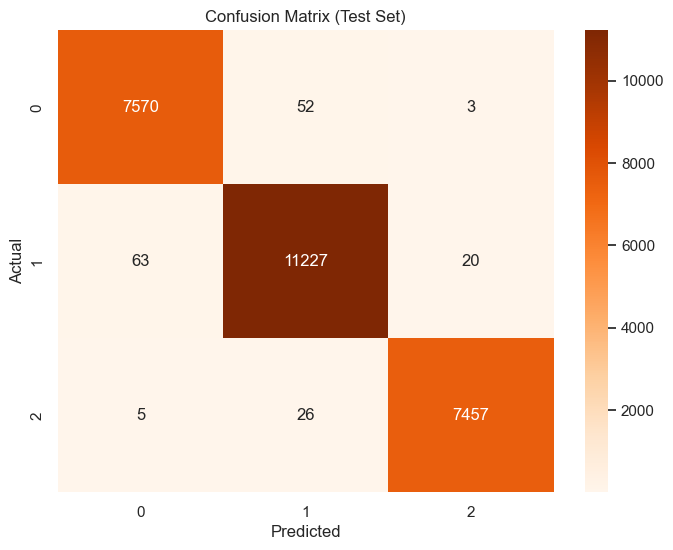

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.9911    0.9928    0.9919      7625
           1     0.9931    0.9927    0.9929     11310
           2     0.9969    0.9959    0.9964      7488

    accuracy                         0.9936     26423
   macro avg     0.9937    0.9938    0.9937     26423
weighted avg     0.9936    0.9936    0.9936     26423



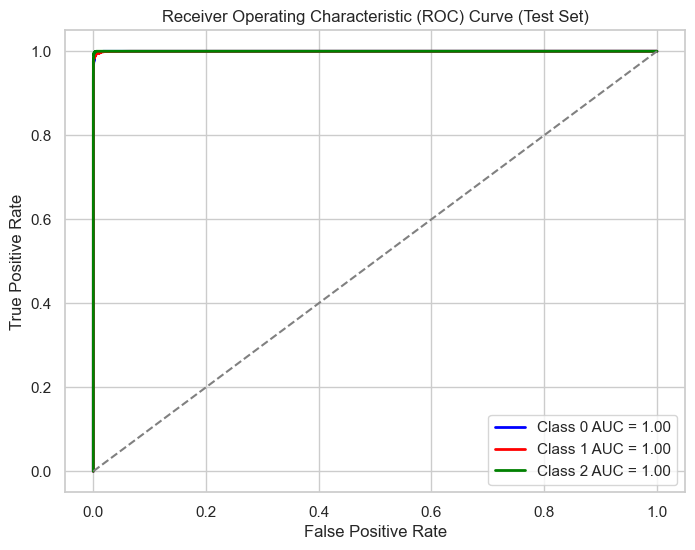

In [48]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
import matplotlib.pyplot as plt

# Binarize the target variable for multi-class AUC-ROC
y_test_binarized = lb.transform(y_test)

# Predict on the original (unbalanced) test set
y_test_pred = rf.predict(X_test)

# Test Accuracy 
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix for Test Set (formatted with '.d' for integers)
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='.0f', cmap='Oranges', xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report for Test Set with 4 decimal places
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# AUC-ROC for Test Set
fpr_test, tpr_test, roc_auc_test = {}, {}, {}
for i in range(len(lb.classes_)):
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_binarized[:, i], rf.predict_proba(X_test)[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot AUC-ROC for Test Set
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i in range(len(lb.classes_)):
    plt.plot(fpr_test[i], tpr_test[i], color=colors[i], lw=2, label='Class {} AUC = {:.2f}'.format(lb.classes_[i], roc_auc_test[i]))

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve (Test Set)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [50]:
from lightgbm import LGBMClassifier

# Initialize the LightGBM model
lgb_model = LGBMClassifier(random_state=42)

# Train the model on the balanced training data
lgb_model.fit(X_train_balanced, y_train_balanced)

print("LightGBM model successfully trained on balanced data.")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1739
[LightGBM] [Info] Number of data points in the train set: 135612, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM model successfully trained on balanced data.


Training Accuracy: 0.9966

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9978    0.9962     45204
           1     0.9977    0.9922    0.9950     45204
           2     0.9975    0.9997    0.9986     45204

    accuracy                         0.9966    135612
   macro avg     0.9966    0.9966    0.9966    135612
weighted avg     0.9966    0.9966    0.9966    135612

Confusion Matrix:
[[45104    94     6]
 [  244 44853   107]
 [    4     9 45191]]


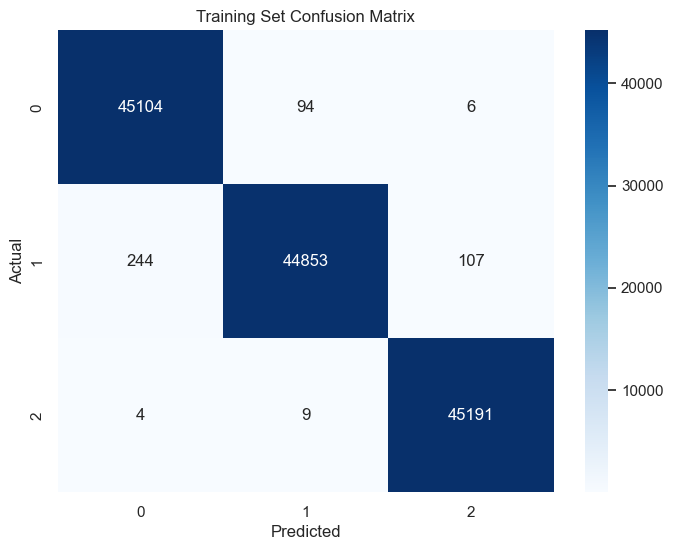

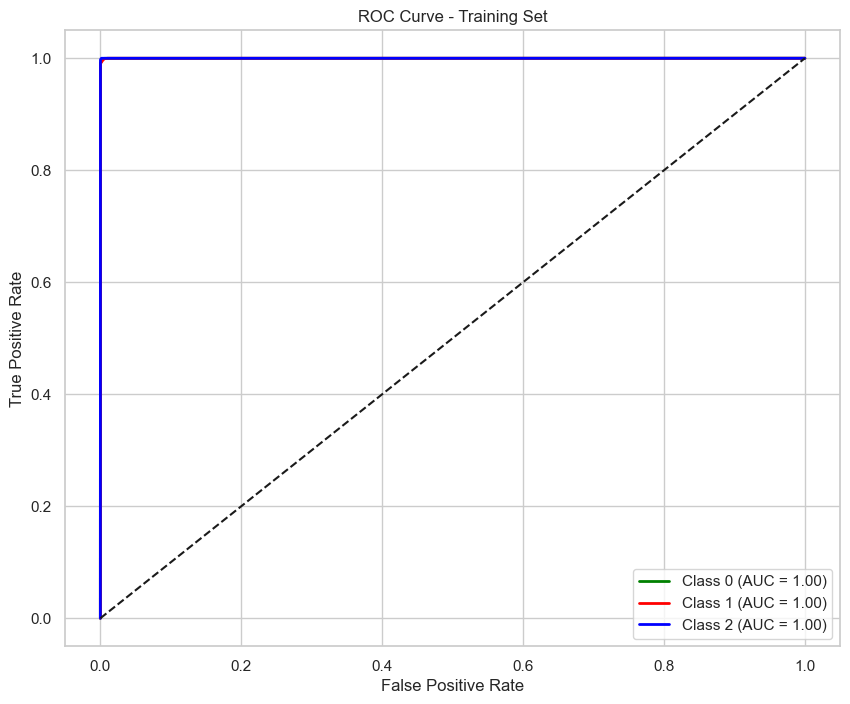

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict on training set
y_train_pred = lgb_model.predict(X_train_balanced)

# Accuracy
train_acc = accuracy_score(y_train_balanced, y_train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_train_balanced, y_train_pred, digits=4))

# Confusion Matrix
cm_train = confusion_matrix(y_train_balanced, y_train_pred)
print("Confusion Matrix:")
print(cm_train)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title("Training Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve and AUC
y_train_prob = lgb_model.predict_proba(X_train_balanced)
y_train_bin = label_binarize(y_train_balanced, classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(10, 8))
colors = ['green', 'red', 'blue']
for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Training Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Test Accuracy: 0.9956

Classification Report:
              precision    recall  f1-score   support

           0     0.9915    0.9961    0.9938      7625
           1     0.9972    0.9928    0.9950     11310
           2     0.9973    0.9993    0.9983      7488

    accuracy                         0.9956     26423
   macro avg     0.9954    0.9961    0.9957     26423
weighted avg     0.9956    0.9956    0.9956     26423

Confusion Matrix:
[[ 7595    29     1]
 [   62 11229    19]
 [    3     2  7483]]


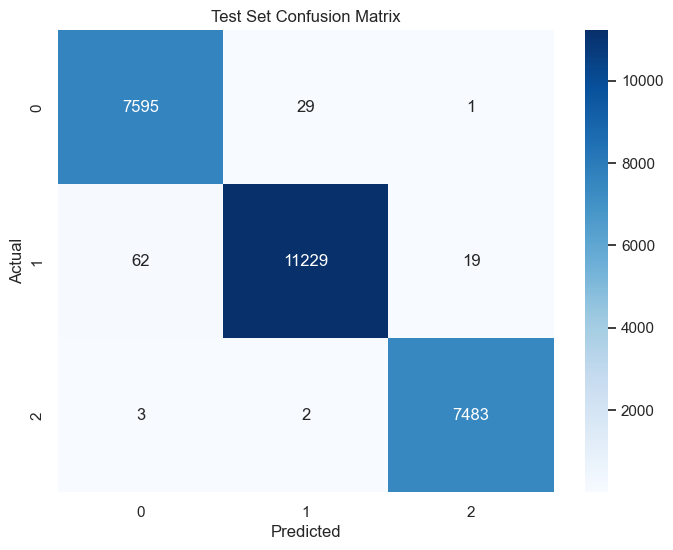

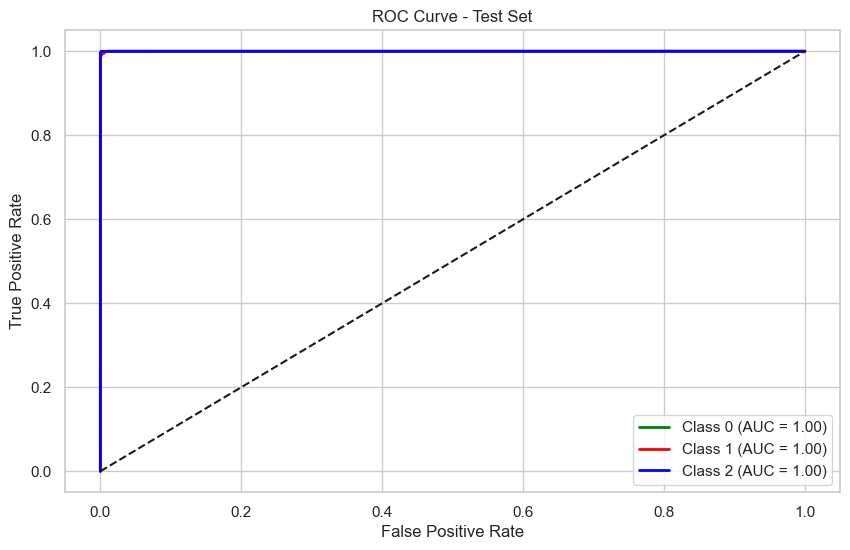

In [52]:
# Predict on test set
y_test_pred = lgb_model.predict(X_test)

# Accuracy
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm_test)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve and AUC
y_test_prob = lgb_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'blue']
for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [53]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Define RandomForest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Define LightGBM model
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42)

# Create the ensemble model using soft voting
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('lgb', lgb_model), ('lr', lr_model)],
    voting='soft'  # Use 'soft' voting to enable prediction probabilities
)

# Train the ensemble model on the balanced data
ensemble_model.fit(X_train_balanced, y_train_balanced)

print("Ensemble model training complete!")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1739
[LightGBM] [Info] Number of data points in the train set: 135612, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Ensemble model training complete!


Training Set Accuracy: 0.9982

Training Set Classification Report:
              precision    recall  f1-score   support

           0     0.9977    0.9989    0.9983     45204
           1     0.9988    0.9958    0.9973     45204
           2     0.9981    0.9998    0.9989     45204

    accuracy                         0.9982    135612
   macro avg     0.9982    0.9982    0.9982    135612
weighted avg     0.9982    0.9982    0.9982    135612


Training Set Confusion Matrix:
[[45153    51     0]
 [  101 45016    87]
 [    5     5 45194]]


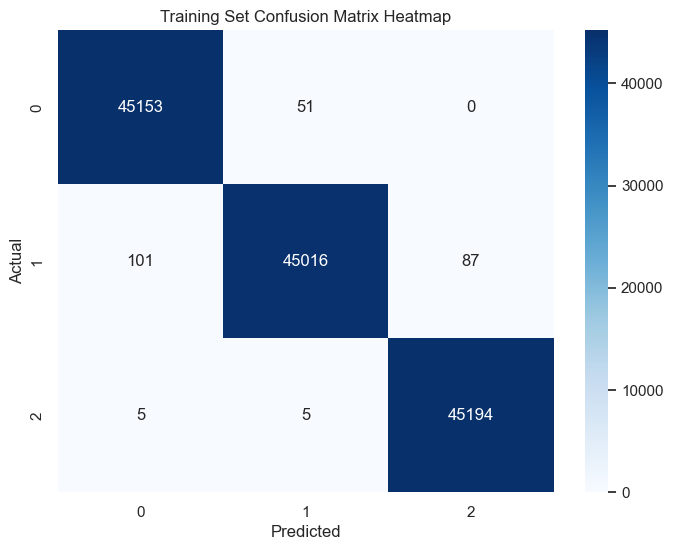

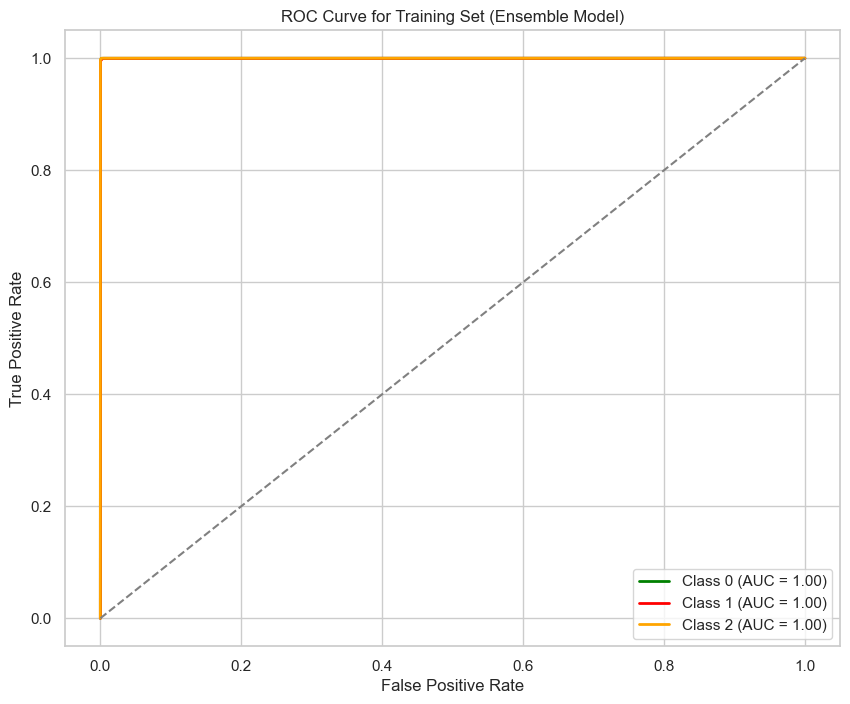

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Predict on the training set
y_pred_train = ensemble_model.predict(X_train_balanced)

# Training Set Evaluation

# Accuracy
accuracy_train = accuracy_score(y_train_balanced, y_pred_train)
print(f"Training Set Accuracy: {accuracy_train:.4f}")

# Classification Report
print("\nTraining Set Classification Report:")
print(classification_report(y_train_balanced, y_pred_train, digits=4))

# Confusion Matrix
cm_train = confusion_matrix(y_train_balanced, y_pred_train)
print("\nTraining Set Confusion Matrix:")
print(cm_train)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title("Training Set Confusion Matrix Heatmap")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Predict probabilities for ROC curve
y_train_prob = ensemble_model.predict_proba(X_train_balanced)

# Binarize y_train for ROC AUC computation
y_train_binarized = label_binarize(y_train_balanced, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr_train = {}
tpr_train = {}
roc_auc_train = {}
for i in range(3):  # As you have 3 classes (0, 1, 2)
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

# Plot ROC curves for the training set
plt.figure(figsize=(10, 8))
colors = ['green', 'red', 'orange']  # Custom colors for each class
for i in range(3):
    plt.plot(fpr_train[i], tpr_train[i], color=colors[i], lw=2, label=f'Class {i} (AUC = {roc_auc_train[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title
plt.title('ROC Curve for Training Set (Ensemble Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


Test Set Accuracy: 0.9944

Test Set Classification Report:
              precision    recall  f1-score   support

           0     0.9928    0.9932    0.9930      7625
           1     0.9936    0.9935    0.9935     11310
           2     0.9971    0.9969    0.9970      7488

    accuracy                         0.9944     26423
   macro avg     0.9945    0.9945    0.9945     26423
weighted avg     0.9944    0.9944    0.9944     26423


Test Set Confusion Matrix:
[[ 7573    51     1]
 [   53 11236    21]
 [    2    21  7465]]


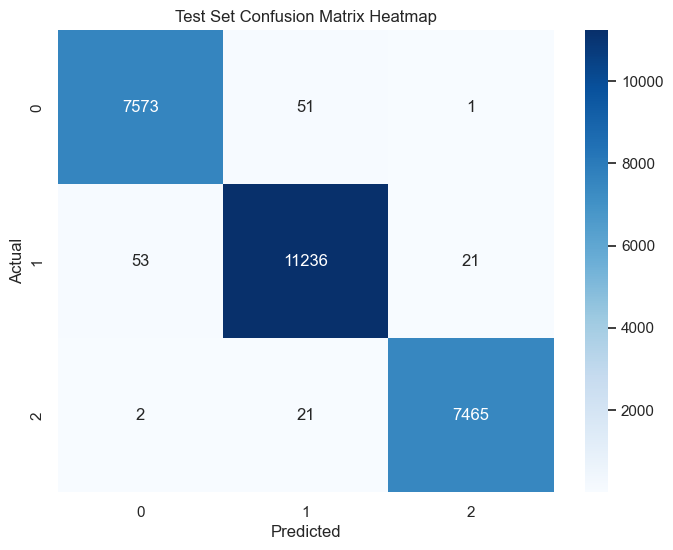

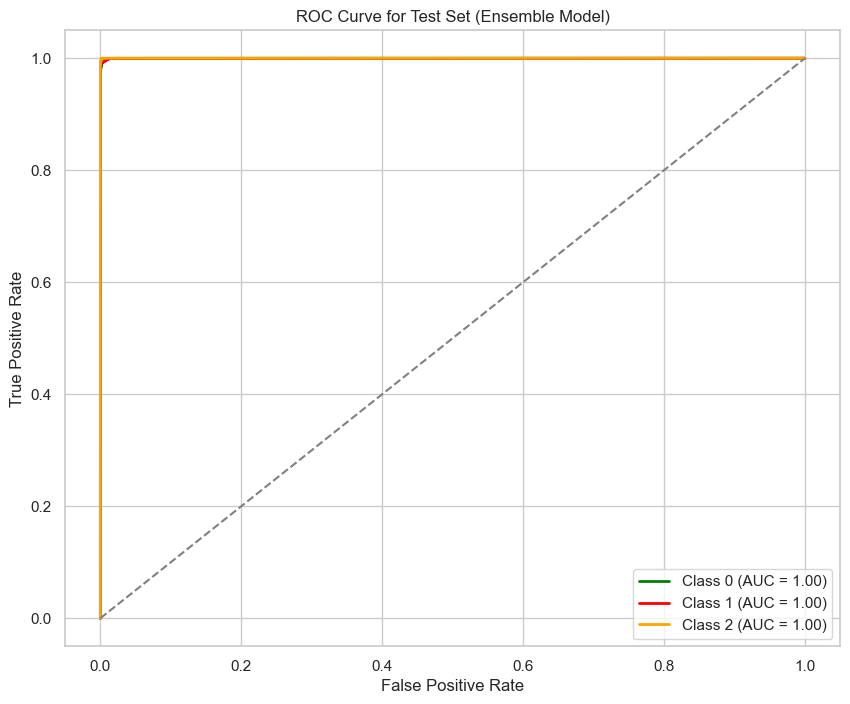

In [55]:
# Predict on the test set
y_pred_test = ensemble_model.predict(X_test)

# Test Set Evaluation

# Accuracy on the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Test Set Accuracy: {accuracy_test:.4f}")

# Classification Report for the test set
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred_test, digits=4))  # Fixed variable and added digits=4

# Confusion Matrix for the test set
cm_test = confusion_matrix(y_test, y_pred_test)
print("\nTest Set Confusion Matrix:")
print(cm_test)

# Plot Confusion Matrix Heatmap for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title("Test Set Confusion Matrix Heatmap")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Predict probabilities for ROC curve (on test set)
y_test_prob = ensemble_model.predict_proba(X_test)

# Binarize y_test for ROC AUC computation
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr_test = {}
tpr_test = {}
roc_auc_test = {}
for i in range(3):  # As you have 3 classes (0, 1, 2)
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_binarized[:, i], y_test_prob[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot ROC curves for the test set
plt.figure(figsize=(10, 8))
colors = ['green', 'red', 'orange']  # Custom colors for each class
for i in range(3):
    plt.plot(fpr_test[i], tpr_test[i], color=colors[i], lw=2, label=f'Class {i} (AUC = {roc_auc_test[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title
plt.title('ROC Curve for Test Set (Ensemble Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 135612, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 135612, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

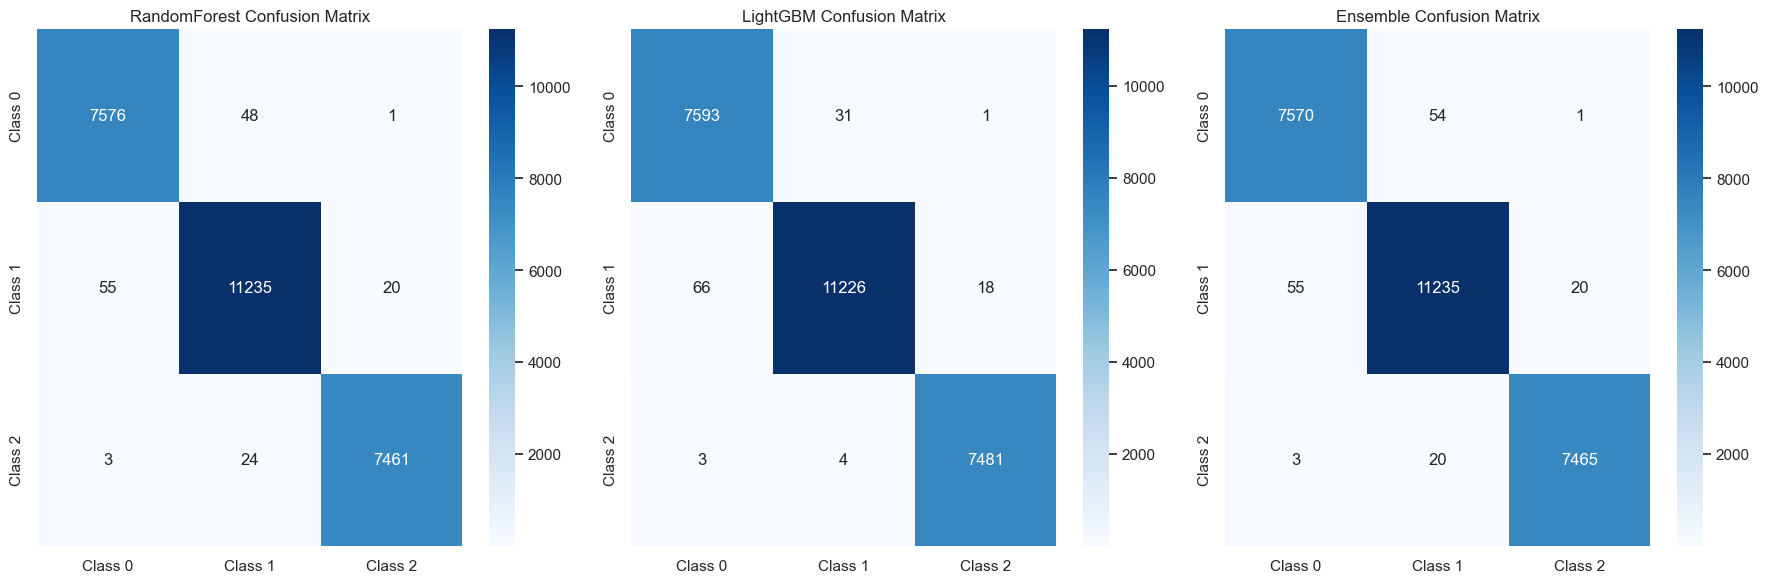

In [54]:
# Train the RandomForest model
rf_model.fit(X_train_balanced, y_train_balanced)

# Train the LightGBM model
lgb_model.fit(X_train_balanced, y_train_balanced)

# Train the Ensemble model
ensemble_model.fit(X_train_balanced, y_train_balanced)

print("Models training completed!")

# Now, let's evaluate the models on the test set.

# Predictions for all models
rf_pred = rf_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
ensemble_pred = ensemble_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
lgb_accuracy = accuracy_score(y_test, lgb_pred)
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)

# Classification Reports
rf_classification_report = classification_report(y_test, rf_pred)
lgb_classification_report = classification_report(y_test, lgb_pred)
ensemble_classification_report = classification_report(y_test, ensemble_pred)

# Confusion Matrices
rf_cm = confusion_matrix(y_test, rf_pred)
lgb_cm = confusion_matrix(y_test, lgb_pred)
ensemble_cm = confusion_matrix(y_test, ensemble_pred)

# Print results
print("RandomForest Accuracy:", rf_accuracy)
print("LightGBM Accuracy:", lgb_accuracy)
print("Ensemble Accuracy:", ensemble_accuracy)

print("\nRandomForest Classification Report:\n", rf_classification_report)
print("\nLightGBM Classification Report:\n", lgb_classification_report)
print("\nEnsemble Classification Report:\n", ensemble_classification_report)

# Plot confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax[0].set_title("RandomForest Confusion Matrix")

sns.heatmap(lgb_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax[1].set_title("LightGBM Confusion Matrix")

sns.heatmap(ensemble_cm, annot=True, fmt='d', cmap='Blues', ax=ax[2], xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax[2].set_title("Ensemble Confusion Matrix")

plt.tight_layout()
plt.show()


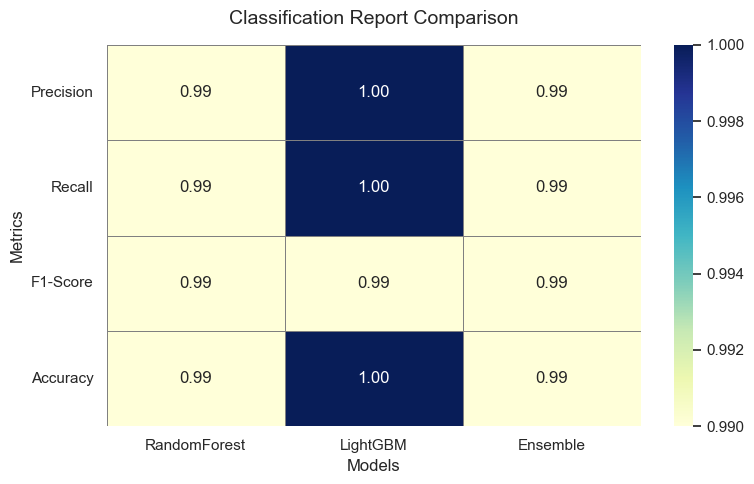

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Classification performance data
data = {
    "RandomForest": [0.99, 0.99, 0.99, 0.99],
    "LightGBM": [1.00, 1.00, 0.99, 1.00],
    "Ensemble": [0.99, 0.99, 0.99, 0.99]
}

metrics = ["Precision", "Recall", "F1-Score", "Accuracy"]

# Create DataFrame
df = pd.DataFrame(data, index=metrics)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True,
            linewidths=0.5, linecolor="gray")

plt.title("Classification Report Comparison", fontsize=14, pad=15)
plt.ylabel("Metrics", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# multiclassification

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# Load the data
df = pd.read_csv("RansomFEN-QFM_dataset.csv")

In [72]:
print(df.columns.tolist())


['Time', 'Protocol', 'Flag', 'Family', 'Clusters', 'SeedAddress', 'ExpAddress', 'BTC', 'USD', 'Netflow_Bytes', 'IPaddress', 'Threats', 'Port', 'Prediction', 'BTC_USD_Ratio', 'Total_Bytes', 'hour_of_day', 'day_of_week', 'Mean_BTC', 'Mean_USD', 'Mean_Netflow_Bytes', 'QFM_0', 'QFM_1', 'QFM_2', 'QFM_3', 'QFM_4', 'QFM_5', 'QFM_6', 'RZ_BTC_USD_Ratio', 'RZ_Total_Bytes', 'RZ_hour_of_day', 'RZ_day_of_week', 'RZ_Mean_BTC', 'RZ_Mean_USD', 'RZ_Mean_Netflow_Bytes']


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier



# Features & target
X = df.drop(columns=['Prediction'])
y = df['Prediction']

# Separate numeric & categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Pipeline with model
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
clf.fit(X_train, y_train)

print("Train Accuracy:", clf.score(X_train, y_train))
print("Test Accuracy:", clf.score(X_test, y_test))



Train Accuracy: 0.9978617113878061
Test Accuracy: 0.9934905196230557


In [74]:
from sklearn.model_selection import train_test_split

# Define features and target
features = df.drop(columns=['Family'])  # All columns except Family
target = df['Family']                   # Only Family column as target


In [75]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

# 1. Split Data 
X_train, X_test, y_train, y_test = train_test_split(
    features, target, 
    test_size=0.2, 
    random_state=42
)

# 2. Display Original Distribution
print("Original Distribution (Train):", Counter(y_train))

# 3. Apply Borderline-SMOTE Only to Training Data
smote = BorderlineSMOTE(kind='borderline-1', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Display Balanced Distribution
print("Balanced Distribution (Train):", Counter(y_train_resampled))

# 5. Verify Test Set Remains Unchanged
print("Test Set Distribution (Unmodified):", Counter(y_test))

Original Distribution (Train): Counter({7: 18534, 10: 14026, 11: 11907, 6: 9334, 4: 8153, 2: 7670, 0: 7288, 1: 7254, 8: 6627, 5: 5597, 9: 5505, 3: 3797})


C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Balanced Distribution (Train): Counter({7: 18534, 10: 14026, 11: 11907, 6: 9334, 4: 8153, 2: 7670, 0: 7288, 1: 7254, 8: 6627, 5: 5597, 9: 5505, 3: 3797})
Test Set Distribution (Unmodified): Counter({7: 4617, 10: 3484, 11: 2985, 6: 2363, 4: 2047, 1: 1897, 2: 1883, 0: 1796, 8: 1673, 5: 1382, 9: 1380, 3: 916})


In [76]:
df

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,...,QFM_4,QFM_5,QFM_6,RZ_BTC_USD_Ratio,RZ_Total_Bytes,RZ_hour_of_day,RZ_day_of_week,RZ_Mean_BTC,RZ_Mean_USD,RZ_Mean_Netflow_Bytes
0,1.783576,1,0,11,1,2,1,-0.532249,-0.748207,-0.990255,...,1.0,1.0,1.0,0.002000,57814424,2,2,19.485966,10631.441982,1765.652162
1,1.159232,1,0,11,1,2,1,-0.532249,-0.747889,-0.988752,...,1.0,1.0,1.0,0.001984,57814424,16,1,19.485966,10631.441982,1765.652162
2,0.534887,1,0,11,1,2,1,-0.532249,-0.747571,-0.989253,...,1.0,1.0,1.0,0.001969,57814424,6,1,19.485966,10631.441982,1765.652162
3,-0.089458,1,0,11,1,2,1,-0.532249,-0.747253,-0.985247,...,1.0,1.0,1.0,0.001953,57814424,20,0,19.485966,10631.441982,1765.652162
4,2.220618,1,0,11,1,2,1,-0.532249,-0.746935,-0.988252,...,1.0,1.0,1.0,0.001938,57814424,9,2,19.485966,10631.441982,1765.652162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132110,0.722190,0,2,8,3,1,5,7.685618,-0.744071,-0.273069,...,1.0,1.0,1.0,0.576087,57814424,9,1,35.430241,10984.773614,2019.623614
132111,0.722190,0,2,8,3,1,5,7.789313,-0.743594,-0.267560,...,1.0,1.0,1.0,0.577061,57814424,9,1,35.430241,10984.773614,2019.623614
132112,0.722190,0,2,8,3,1,5,7.893009,-0.743117,-0.262051,...,1.0,1.0,1.0,0.578014,57814424,9,1,35.430241,10984.773614,2019.623614
132113,0.722190,0,2,8,3,1,5,7.996704,-0.742640,-0.256541,...,1.0,1.0,1.0,0.578947,57814424,9,1,35.430241,10984.773614,2019.623614


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.20467016567606425
Test Set Accuracy: 0.20425386973470083
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.42      0.52      1817
           1       0.00      0.00      0.00      1830
           2       0.00      0.00      0.00      1911
           3       0.00      0.00      0.00       943
           4       0.00      0.00      0.00      2040
           5       0.00      0.00      0.00      1396
           6       0.00      0.00      0.00      2339
           7       0.23      1.00      0.38      4630
           8       0.00      0.00      0.00      1660
           9       0.00      0.00      0.00      1377
          10       0.00      0.00      0.00      3502
          11       0.00      0.00      0.00      2978

    accuracy                           0.20 

C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


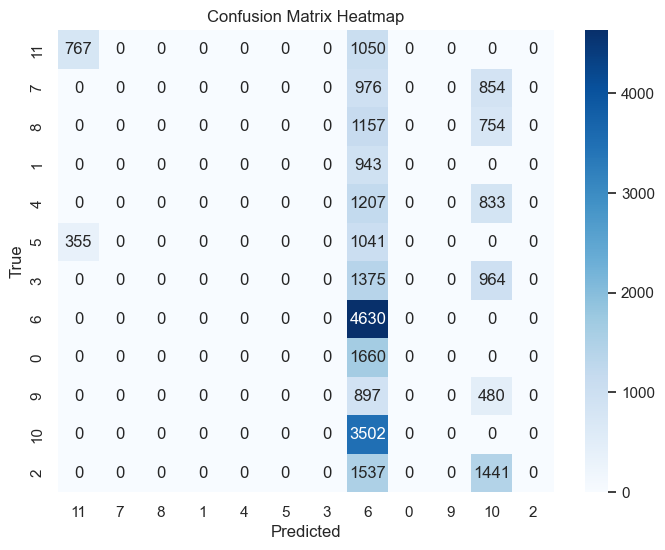

In [77]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your dataframe and 'Family' is the target column
# Define feature set and target
X = df.drop('Family', axis=1)
y = df['Family']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l2'],  # L2 regularization 
    'solver': ['lbfgs', 'liblinear']  # Solvers to be tested
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the model with GridSearchCV
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Make predictions on the test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Evaluate the model
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("Test Set Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Heatmap of the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=df1['Family'].unique(), yticklabels=df1['Family'].unique())
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [78]:
# ---------- Training ----------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

# Fit the model
grid_search.fit(X_train, y_train)

# Output best params and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Confirmation message
print("✅ Logistic Regression training completed successfully.")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.20467016567606425
✅ Logistic Regression training completed successfully.


✅ Train Set Accuracy: 0.2047
📋 Train Set Classification Report:
              precision    recall  f1-score   support

         APT       0.68      0.43      0.52      7267
    CryptXXX       0.00      0.00      0.00      7321
   DMALocker       0.00      0.00      0.00      7642
        EDA2       0.00      0.00      0.00      3770
      Flyper       0.00      0.00      0.00      8160
       Globe       0.00      0.00      0.00      5583
      JigSaw       0.00      0.00      0.00      9358
       Locky       0.23      1.00      0.38     18521
       Other       0.00      0.00      0.00      6640
        Razy       0.00      0.00      0.00      5508
      SamSam       0.00      0.00      0.00     14008
    WannaCry       0.00      0.00      0.00     11914

    accuracy                           0.20    105692
   macro avg       0.08      0.12      0.07    105692
weighted avg       0.09      0.20      0.10    105692

🧮 Train Set Confusion Matrix:
 [[ 3111     0     0     0     0     0 

C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u21629545\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


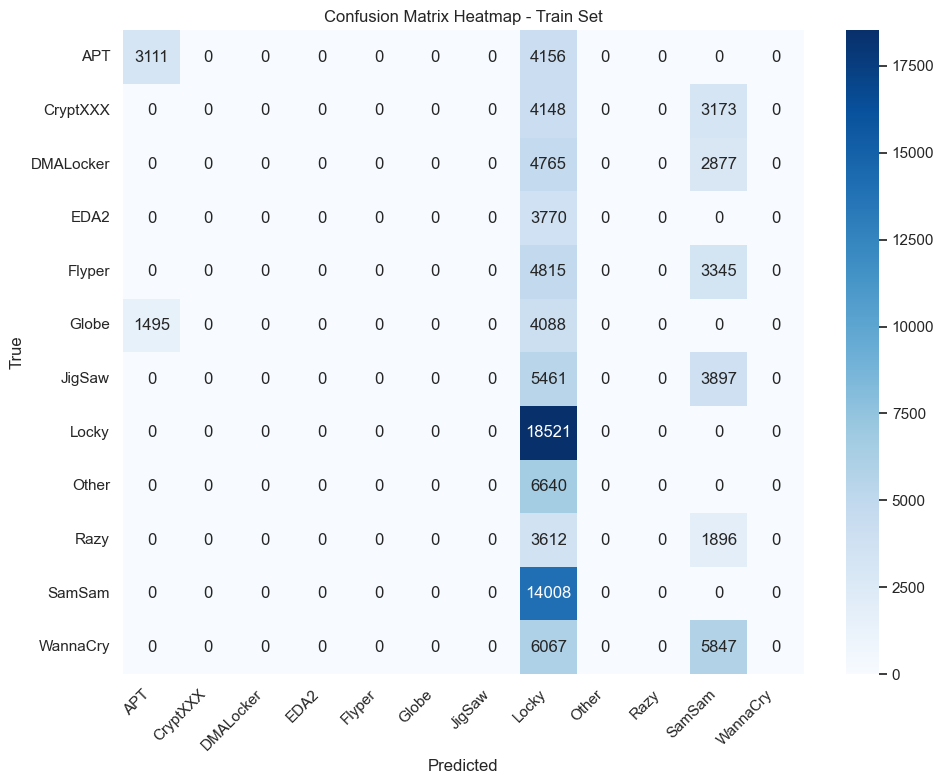

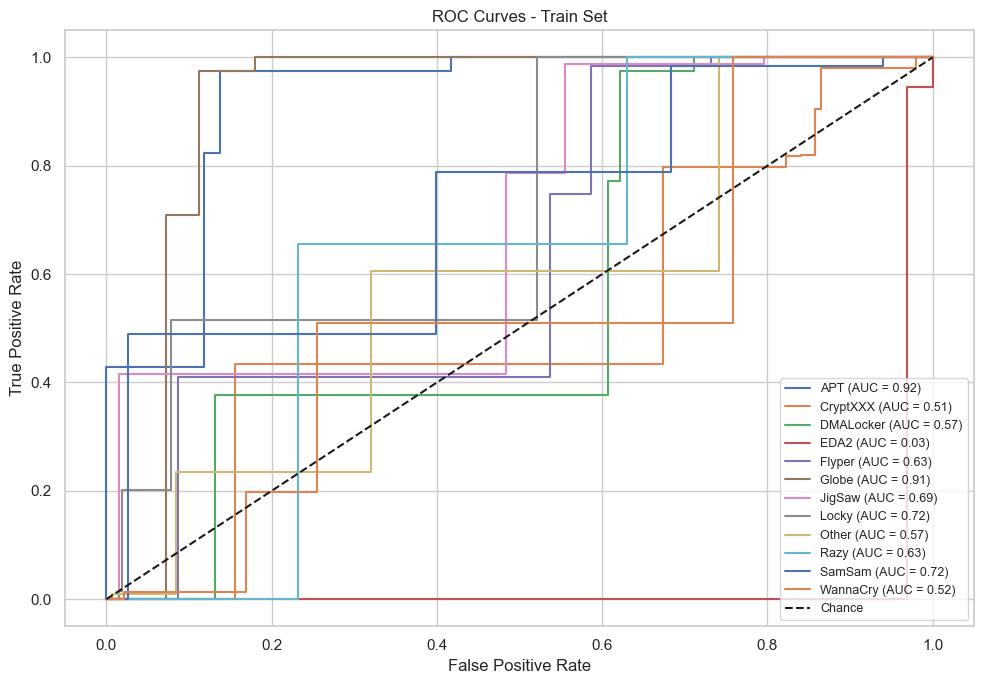

In [79]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Class ID to Name Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
inv_class_mapping = {v: k for k, v in class_mapping.items()}  # If needed later
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Predict on Training Set ----------
y_pred_train = grid_search.best_estimator_.predict(X_train)
y_proba_train = grid_search.best_estimator_.predict_proba(X_train)

# ---------- Accuracy ----------
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"✅ Train Set Accuracy: {train_accuracy:.4f}")

# ---------- Classification Report ----------
print("📋 Train Set Classification Report:")
print(classification_report(y_train, y_pred_train, target_names=class_labels))

# ---------- Confusion Matrix ----------
cm_train = confusion_matrix(y_train, y_pred_train)
print("🧮 Train Set Confusion Matrix:\n", cm_train)

# ---------- Heatmap ----------
plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix Heatmap - Train Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_train_bin = label_binarize(y_train, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_proba_train[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Train Set')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


✅ Test Set Accuracy: 0.8209
📋 Test Set Classification Report:
              precision    recall  f1-score   support

         APT       1.00      1.00      1.00      1379
    CryptXXX       1.00      0.88      0.93      1387
   DMALocker       1.00      0.52      0.69      1231
        EDA2       1.00      0.99      1.00       732
      Flyper       0.72      0.37      0.49      1434
       Globe       1.00      1.00      1.00       510
      JigSaw       1.00      0.95      0.97      1550
       Locky       0.55      0.93      0.69      3428
       Other       1.00      1.00      1.00      1249
        Razy       1.00      1.00      1.00      1031
      SamSam       0.99      0.98      0.99      2653
    WannaCry       0.61      0.41      0.49      2249

    accuracy                           0.82     18833
   macro avg       0.91      0.84      0.85     18833
weighted avg       0.85      0.82      0.81     18833

🧮 Test Set Confusion Matrix:
 [[1379    0    0    0    0    0    0    0

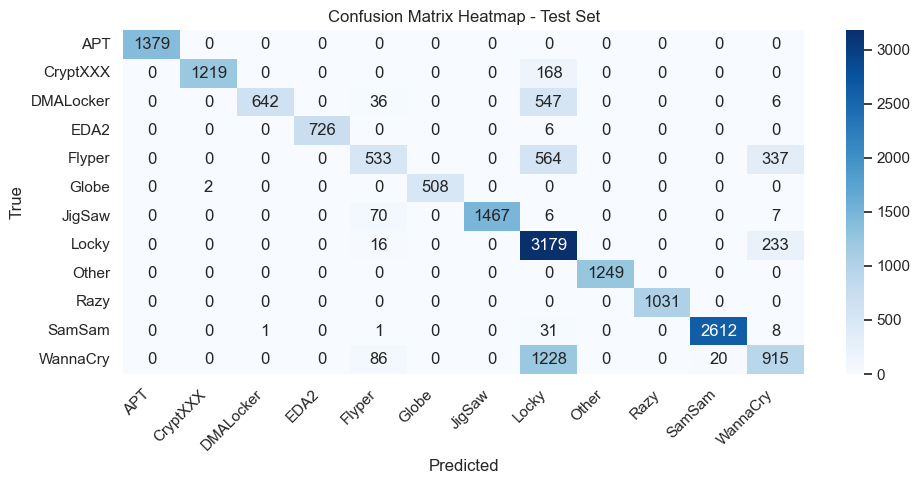

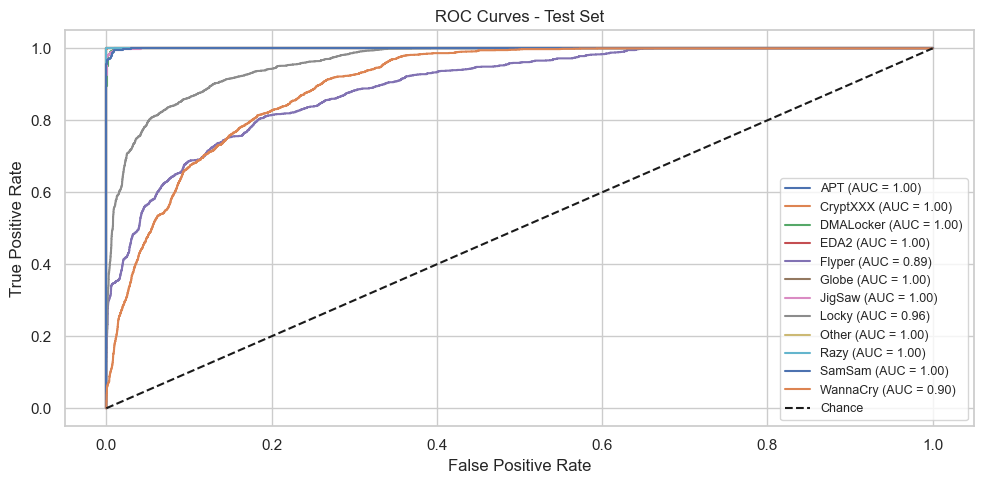

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Class ID to Name Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Make Predictions on Test Set ----------
y_pred = grid_search.best_estimator_.predict(X_test)
y_proba = grid_search.best_estimator_.predict_proba(X_test)

# ---------- Accuracy ----------
print(f"✅ Test Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# ---------- Classification Report ----------
print("📋 Test Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_test, y_pred)
print("🧮 Test Set Confusion Matrix:\n", cm)

# ---------- Confusion Matrix Heatmap ----------
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix Heatmap - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_test_bin = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 5))
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


In [80]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import seaborn as sns
import matplotlib.pyplot as plt


# Initialize classifiers with regularization and complexity control
rf_model = RandomForestClassifier(random_state=42, max_depth=10, max_samples=0.8)
knn_model = KNeighborsClassifier(n_neighbors=15)
lr_model = LogisticRegression(random_state=42, C=0.1, penalty='l2', solver='liblinear')

# Create the voting classifier (Soft Voting)
voting_clf = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('knn', knn_model),
    ('lr', lr_model)
], voting='soft')

# Fit the ensemble model on resampled data
voting_clf.fit(X_train_resampled, y_train_resampled)



VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=10,
                                                     max_samples=0.8,
                                                     random_state=42)),
                             ('knn', KNeighborsClassifier(n_neighbors=15)),
                             ('lr',
                              LogisticRegression(C=0.1, random_state=42,
                                                 solver='liblinear'))],
                 voting='soft')

✅ Training Accuracy: 1.0000
📋 Training Classification Report:
              precision    recall  f1-score   support

         APT       1.00      1.00      1.00      7288
    CryptXXX       1.00      1.00      1.00      7254
   DMALocker       1.00      1.00      1.00      7670
        EDA2       1.00      1.00      1.00      3797
      Flyper       1.00      1.00      1.00      8153
       Globe       1.00      1.00      1.00      5597
      JigSaw       1.00      1.00      1.00      9334
       Locky       1.00      1.00      1.00     18534
       Other       1.00      1.00      1.00      6627
        Razy       1.00      1.00      1.00      5505
      SamSam       1.00      1.00      1.00     14026
    WannaCry       1.00      1.00      1.00     11907

    accuracy                           1.00    105692
   macro avg       1.00      1.00      1.00    105692
weighted avg       1.00      1.00      1.00    105692

🧮 Training Confusion Matrix:
 [[ 7288     0     0     0     0     0    

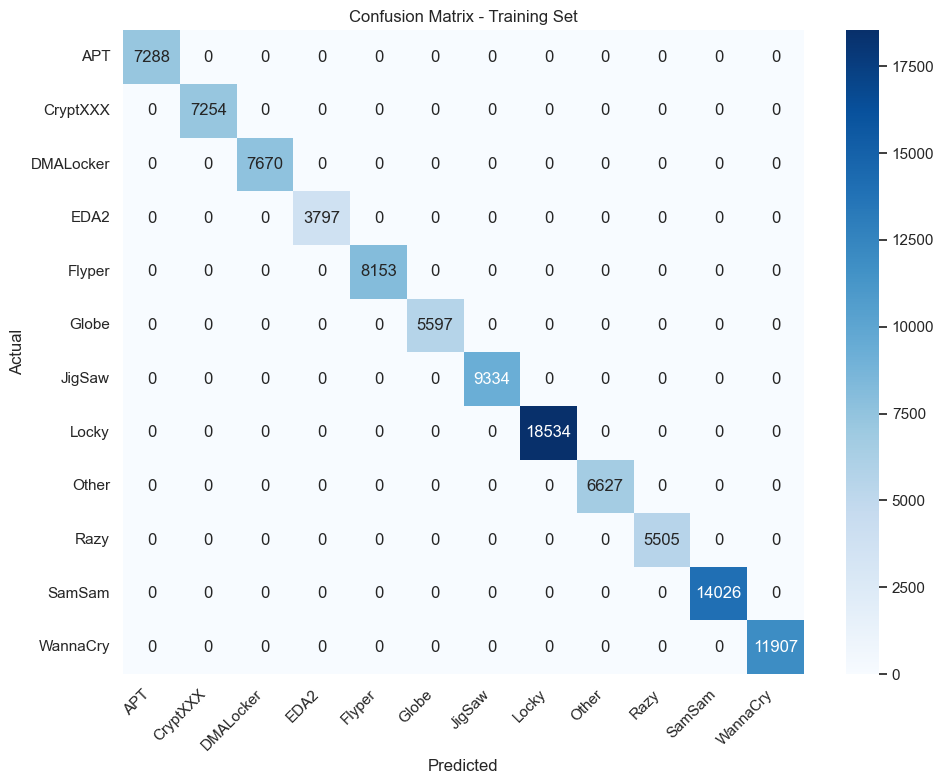

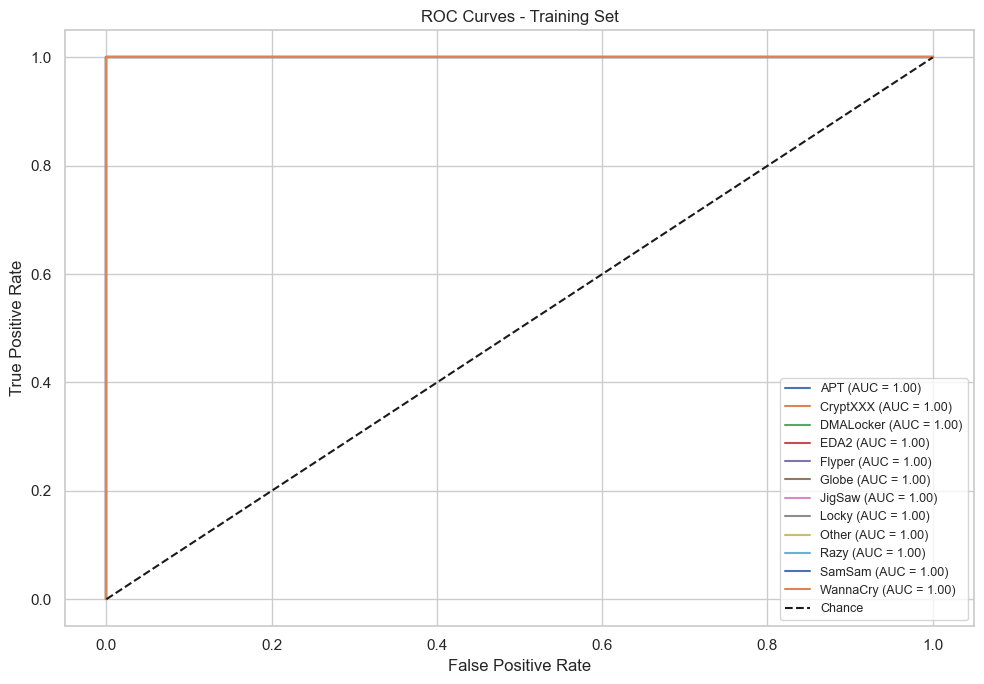

In [81]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Class Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Predict on Training Data ----------
y_train_pred = voting_clf.predict(X_train_resampled)
y_train_proba = voting_clf.predict_proba(X_train_resampled)

# ---------- Accuracy ----------
accuracy = accuracy_score(y_train_resampled, y_train_pred)
print(f"✅ Training Accuracy: {accuracy:.4f}")

# ---------- Classification Report ----------
print("📋 Training Classification Report:")
print(classification_report(y_train_resampled, y_train_pred, target_names=class_labels))

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_train_resampled, y_train_pred)
print("🧮 Training Confusion Matrix:\n", cm)

# ---------- Confusion Matrix Heatmap ----------
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_bin = label_binarize(y_train_resampled, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_train_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Training Set')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


✅ Test Accuracy: 0.9967
📋 Test Classification Report:
              precision    recall  f1-score   support

         APT     1.0000    1.0000    1.0000      1379
    CryptXXX     0.9774    1.0000    0.9886      1387
   DMALocker     0.9984    1.0000    0.9992      1231
        EDA2     1.0000    1.0000    1.0000       732
      Flyper     0.9945    1.0000    0.9972      1434
       Globe     1.0000    0.9980    0.9990       510
      JigSaw     0.9994    0.9994    0.9994      1550
       Locky     1.0000    0.9831    0.9915      3428
       Other     1.0000    1.0000    1.0000      1249
        Razy     1.0000    1.0000    1.0000      1031
      SamSam     0.9996    0.9992    0.9994      2653
    WannaCry     0.9916    0.9996    0.9956      2249

    accuracy                         0.9967     18833
   macro avg     0.9967    0.9983    0.9975     18833
weighted avg     0.9967    0.9967    0.9967     18833

🧮 Test Confusion Matrix:
 [[1379    0    0    0    0    0    0    0    0    0  

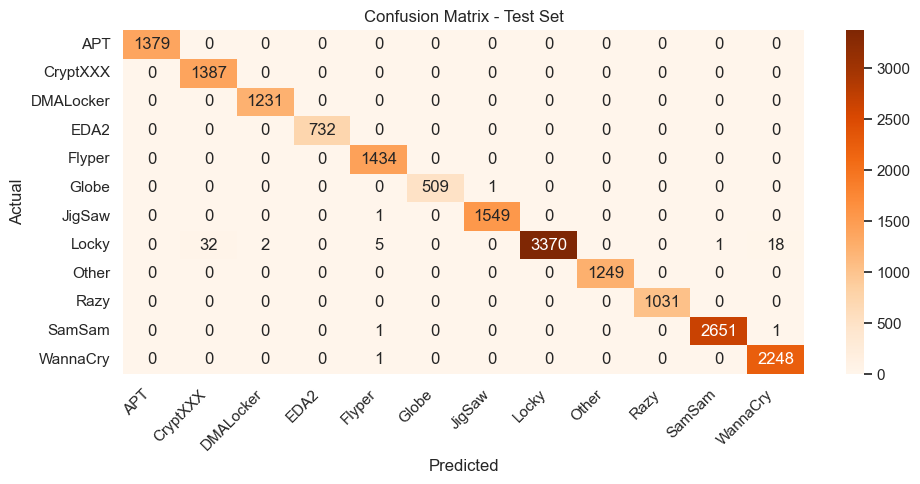

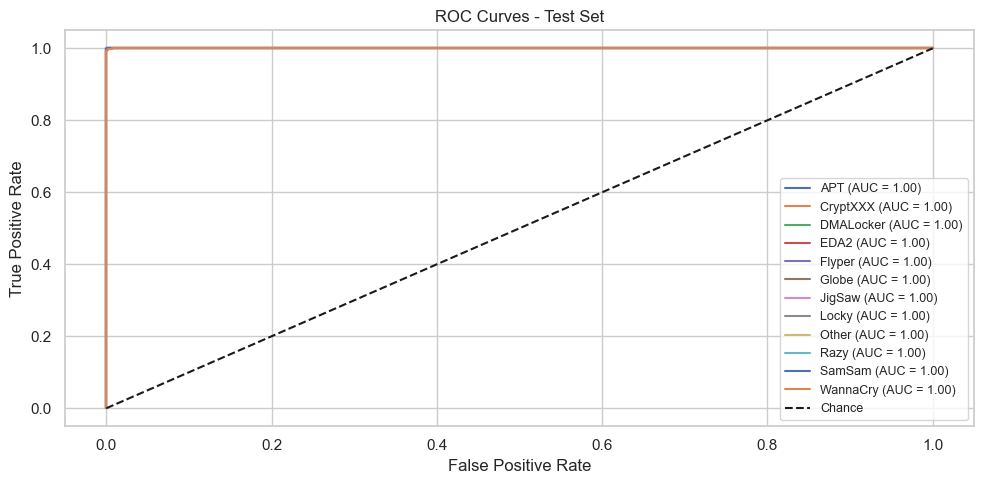

In [44]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Class Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Predict on Test Data ----------
y_test_pred = voting_clf.predict(X_test)
y_test_proba = voting_clf.predict_proba(X_test)

# ---------- Accuracy ----------
accuracy = accuracy_score(y_test, y_test_pred)
print(f"✅ Test Accuracy: {accuracy:.4f}")

# ---------- Classification Report ----------
print("📋 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_labels, digits=4))

# ---------- Confusion Matrix ----------
cm = confusion_matrix(y_test, y_test_pred)
print("🧮 Test Confusion Matrix:\n", cm)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_bin_test = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin_test[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced'],
    'bootstrap': [True]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_resampled, y_train_resampled)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


# Evaluate on test set
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1817
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00      1911
           3       1.00      1.00      1.00       943
           4       1.00      1.00      1.00      2040
           5       1.00      1.00      1.00      1396
           6       1.00      1.00      1.00      2339
           7       1.00      1.00      1.00      4630
           8       1.00      1.00      1.00      1660
           9       1.00      1.00      1.00      1377
          10       1.00      1.00      1.00      3502
          11       1.00      1.00      1.00      2978

    accuracy                           1.00   

In [83]:
from sklearn.ensemble import RandomForestClassifier

# ---------- Train Random Forest ----------
rf_model = RandomForestClassifier(random_state=42, max_depth=10, max_samples=0.8)
rf_model.fit(X_train_resampled, y_train_resampled)

print("✅ Random Forest training completed on resampled data.")


✅ Random Forest training completed on resampled data.


✅ Train Accuracy: 1.0000
📋 Train Classification Report:
              precision    recall  f1-score   support

         APT       1.00      1.00      1.00      7288
    CryptXXX       1.00      1.00      1.00      7254
   DMALocker       1.00      1.00      1.00      7670
        EDA2       1.00      1.00      1.00      3797
      Flyper       1.00      1.00      1.00      8153
       Globe       1.00      1.00      1.00      5597
      JigSaw       1.00      1.00      1.00      9334
       Locky       1.00      1.00      1.00     18534
       Other       1.00      1.00      1.00      6627
        Razy       1.00      1.00      1.00      5505
      SamSam       1.00      1.00      1.00     14026
    WannaCry       1.00      1.00      1.00     11907

    accuracy                           1.00    105692
   macro avg       1.00      1.00      1.00    105692
weighted avg       1.00      1.00      1.00    105692

🧮 Train Confusion Matrix:
[[ 7288     0     0     0     0     0     0     0  

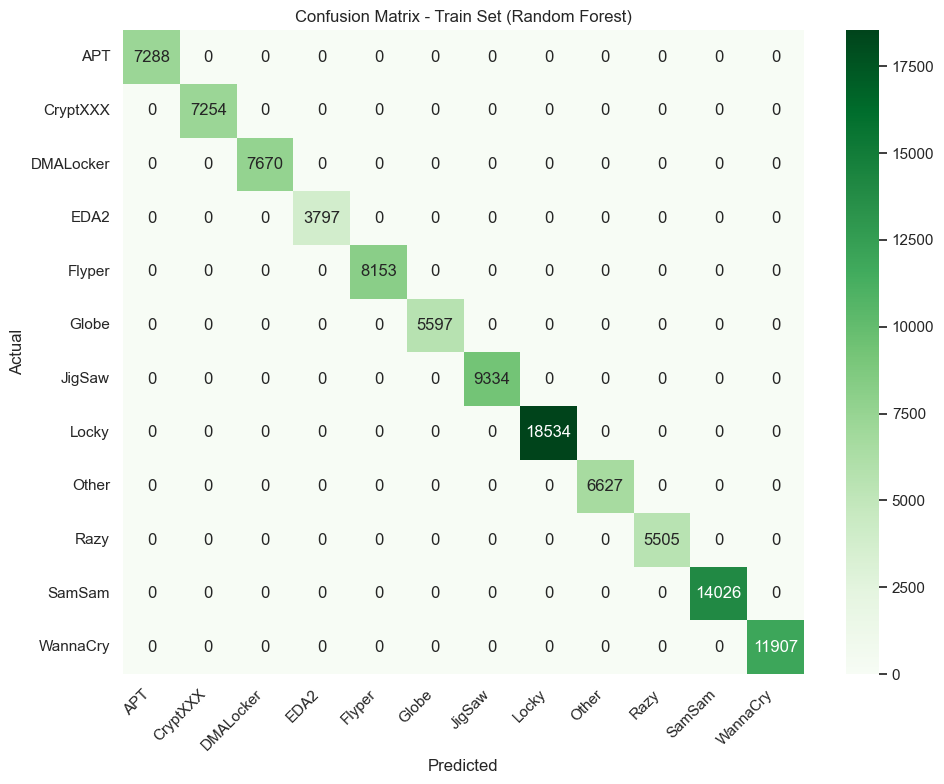

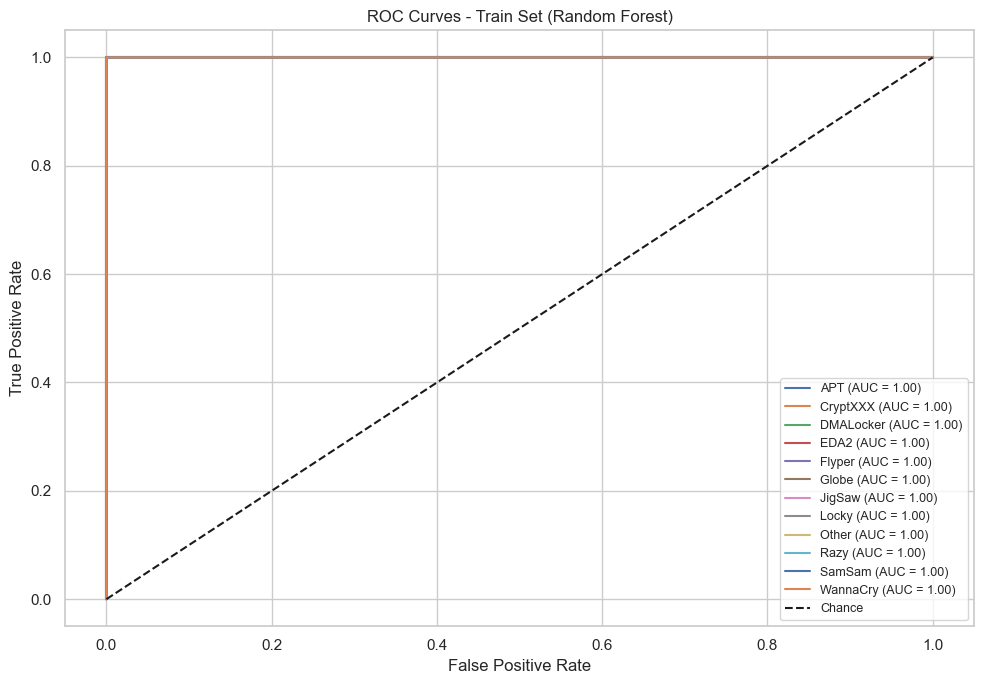

In [84]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Class Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Predict on Train Set ----------
y_train_pred = rf_model.predict(X_train_resampled)
y_train_proba = rf_model.predict_proba(X_train_resampled)

# ---------- Accuracy ----------
train_acc = accuracy_score(y_train_resampled, y_train_pred)
print(f"✅ Train Accuracy: {train_acc:.4f}")

# ---------- Classification Report ----------
print("📋 Train Classification Report:")
print(classification_report(y_train_resampled, y_train_pred, target_names=class_labels))

# ---------- Confusion Matrix ----------
cm_train = confusion_matrix(y_train_resampled, y_train_pred)
print("🧮 Train Confusion Matrix:")
print(cm_train)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Train Set (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_bin_train = label_binarize(y_train_resampled, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin_train[:, i], y_train_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Train Set (Random Forest)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


✅ Test Accuracy: 1.0000
📋 Test Classification Report:
              precision    recall  f1-score   support

         APT       1.00      1.00      1.00      1817
    CryptXXX       1.00      1.00      1.00      1830
   DMALocker       1.00      1.00      1.00      1911
        EDA2       1.00      1.00      1.00       943
      Flyper       1.00      1.00      1.00      2040
       Globe       1.00      1.00      1.00      1396
      JigSaw       1.00      1.00      1.00      2339
       Locky       1.00      1.00      1.00      4630
       Other       1.00      1.00      1.00      1660
        Razy       1.00      1.00      1.00      1377
      SamSam       1.00      1.00      1.00      3502
    WannaCry       1.00      1.00      1.00      2978

    accuracy                           1.00     26423
   macro avg       1.00      1.00      1.00     26423
weighted avg       1.00      1.00      1.00     26423

🧮 Test Confusion Matrix:
[[1817    0    0    0    0    0    0    0    0    0   

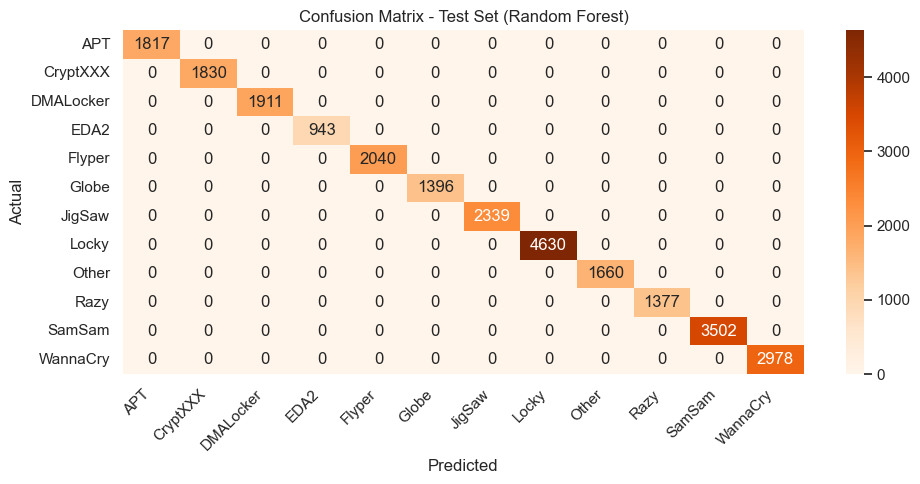

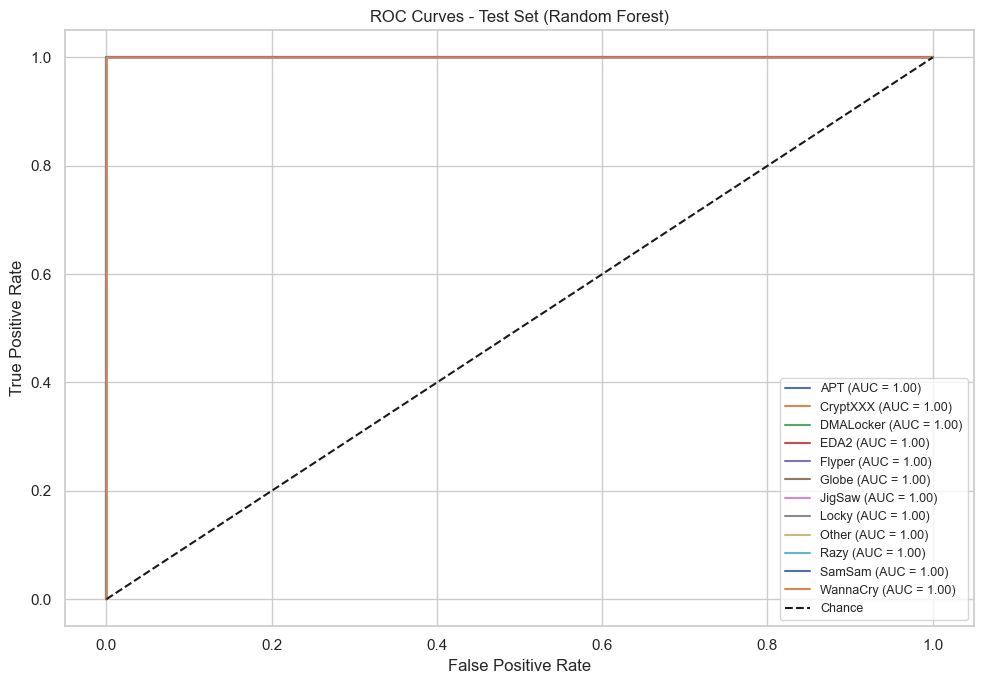

In [85]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Class Mapping ----------
class_mapping = {
    0: 'APT', 1: 'CryptXXX', 2: 'DMALocker', 3: 'EDA2',
    4: 'Flyper', 5: 'Globe', 6: 'JigSaw', 7: 'Locky',
    8: 'Other', 9: 'Razy', 10: 'SamSam', 11: 'WannaCry'
}
class_labels = [class_mapping[i] for i in sorted(class_mapping.keys())]

# ---------- Predict on Test Set ----------
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

# ---------- Accuracy ----------
test_acc = accuracy_score(y_test, y_test_pred)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# ---------- Classification Report ----------
print("📋 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_labels))

# ---------- Confusion Matrix ----------
cm_test = confusion_matrix(y_test, y_test_pred)
print("🧮 Test Confusion Matrix:")
print(cm_test)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Test Set (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- ROC Curves ----------
classes = sorted(class_mapping.keys())
y_bin_test = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin_test[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{class_mapping[classes[i]]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set (Random Forest)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced'],
    'bootstrap': [True]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_resampled, y_train_resampled)  # This defines 'grid'


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'class_weight': ['balanced'],
                         'max_depth': [8, 10, 12],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

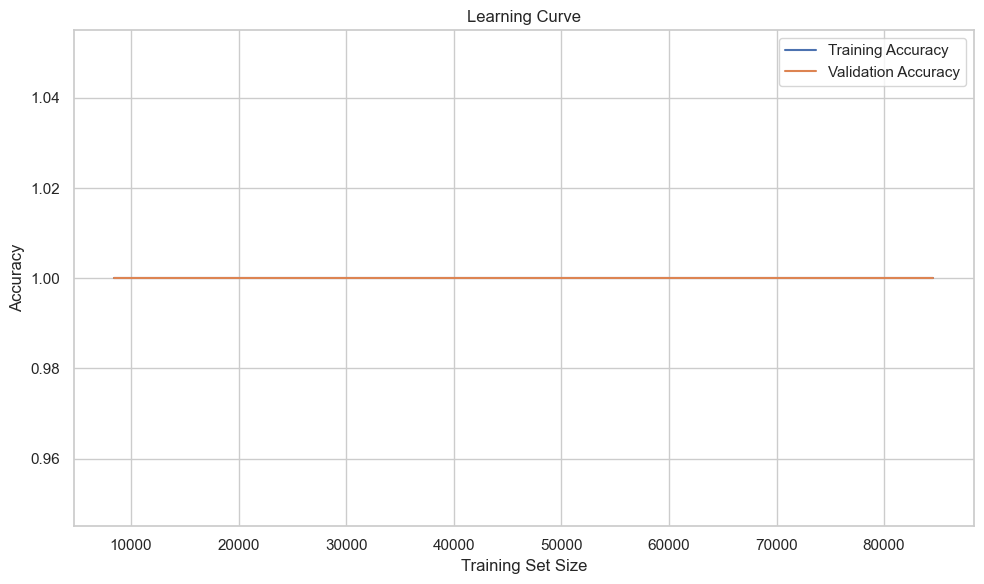

In [87]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=grid.best_estimator_,
    X=X_train_resampled,
    y=y_train_resampled,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
